## Loading Packages 

In [1]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder


import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper

import torch
import torchtuples as tt


from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

import pandas as pd
from IPython.display import display

from sklearn.preprocessing import StandardScaler


from pycox.models import DeepHitSingle


import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from sklearn_pandas import DataFrameMapper
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pycox.models import CoxPH
from pycox.models.loss import CoxPHLoss
from pycox.evaluation import EvalSurv
import time

/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Cleaning

In [2]:
# Define the file paths
malawi_file_path = './nfm/data/Malawi_cleanednew.csv'
zambia_file_path ='./nfm/data/Zambia_cleanednew.csv'
SA_file_path = './nfm/data/SouthAfrica_cleanednew.csv'
zimbabwe_file_path = './nfm/data/Zimbabwe_cleanednew.csv'


# Read the CSV files with specified encoding
zimbabwe_df = pd.read_csv(zimbabwe_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')
malawi_df = pd.read_csv(malawi_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')
zambia_df = pd.read_csv(zambia_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')
sa_df = pd.read_csv(SA_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')  # Adjust encoding as needed

# Display the first few rows of each dataset to verify changes
print("Zimbabwe Data:")
display(zimbabwe_df.head())

print("\nMalawi Data:")
display(malawi_df.head())

print("\nZambia Data:")
display(zambia_df.head())

print("\nSouth Africa Data:")
display(sa_df.head())


Zimbabwe Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,57.034908,0,1,2,0,2,3,1,0,0,...,1,1,0,2,1,1,4,0,2,1
1,39.819302,0,0,2,0,2,3,1,0,1,...,1,1,0,2,2,1,4,0,1,1
2,4.008214,0,0,1,0,2,2,2,1,0,...,1,1,0,2,3,1,4,1,1,1
3,26.151951,0,1,2,0,2,3,1,0,0,...,1,1,0,2,2,0,4,0,2,1
4,44.616016,0,0,2,0,2,3,1,0,0,...,1,1,0,2,1,0,4,0,2,1



Malawi Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,59.301848,0,0,2,1,0,2,1,1,0,...,1,0,1,2,1,0,3,0,1,1
1,22.439425,0,1,2,0,0,3,1,1,0,...,1,0,1,2,1,1,4,0,2,1
2,44.418891,0,1,1,0,0,2,1,0,0,...,1,0,1,2,1,0,4,0,1,1
3,57.724846,0,0,2,0,0,2,1,0,0,...,1,0,0,2,0,1,2,0,1,0
4,20.501027,0,1,1,1,0,1,1,1,0,...,1,0,1,2,1,1,3,0,1,1



Zambia Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,10.973306,0,1,2,0,1,4,1,1,0,...,1,0,0,2,1,1,4,1,2,1
1,13.273101,0,1,0,0,1,1,1,1,0,...,1,1,0,2,1,1,3,0,1,1
2,22.735113,0,1,1,1,1,2,2,0,1,...,1,0,0,2,1,1,4,0,1,1
3,4.271047,0,1,1,0,1,2,2,1,0,...,1,1,0,2,2,1,4,1,2,1
4,28.977413,0,0,3,0,1,3,1,0,0,...,1,0,0,2,1,1,4,0,1,1



South Africa Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,53.979466,0,0,3,1,0,2,2,0,0,...,3,1,0,1,2,0,4,0,1,1
1,51.318275,0,1,1,1,0,1,1,0,1,...,3,0,0,1,0,1,2,0,1,1
2,44.123203,0,1,1,0,0,1,1,0,0,...,3,1,0,1,0,0,2,0,1,1
3,29.864476,0,0,1,0,0,2,1,0,0,...,3,1,0,1,2,0,4,0,1,0
4,5.782341,0,1,0,0,0,1,1,1,0,...,3,0,0,1,1,0,4,1,1,0


In [3]:
# Function to get variable names, types, and percentage of missing values
def get_dataset_info(df):
    info = pd.DataFrame({
        'Variable Name': df.columns,
        'Variable Type': df.dtypes,
        'Percentage Missing': df.isnull().mean() * 100
    })
    return info

In [4]:
# Get info for all four datasets
zimbabwe_info = get_dataset_info(zimbabwe_df)
malawi_info = get_dataset_info(malawi_df)
zambia_info = get_dataset_info(zambia_df)
sa_info = get_dataset_info(sa_df)

# Display the info for each dataset
print("Zimbabwe Dataset Info:")
display(zimbabwe_info)

print("\nMalawi Dataset Info:")
display(malawi_info)

print("\nZambia Dataset Info:")
display(zambia_info)

print("\nSouth Africa Dataset Info:")
display(sa_info)

Zimbabwe Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0



Malawi Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0



Zambia Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0



South Africa Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0


In [5]:
zimbabwe_df.shape

(4436, 26)

In [6]:


# Function to convert variables to categorical, excluding specified columns
def convert_to_categorical(df, exclude_columns):
    for column in df.columns:
        if column not in exclude_columns:
            df[column] = df[column].astype('category')
    return df

# Columns to exclude from conversion
exclude_columns = ['CASEID', 'Unnamed: 0', 'survival_time']

# Convert variables to categorical for all datasets
zimbabwe_df = convert_to_categorical(zimbabwe_df, exclude_columns)
malawi_df = convert_to_categorical(malawi_df, exclude_columns)
zambia_df = convert_to_categorical(zambia_df, exclude_columns)
sa_df = convert_to_categorical(sa_df, exclude_columns)



In [7]:
# Function to delete specified columns from a DataFrame
def delete_columns(df, columns_to_delete):
    df = df.drop(columns=columns_to_delete, errors='ignore')
    return df

# Columns to delete
columns_to_delete = ['CASEID']

# Delete the columns from each dataset
zimbabwe_df = delete_columns(zimbabwe_df, columns_to_delete)
malawi_df = delete_columns(malawi_df, columns_to_delete)
zambia_df = delete_columns(zambia_df, columns_to_delete)
sa_df = delete_columns(sa_df, columns_to_delete)

# Display the first few rows of each dataset to verify deletion
print("\nZimbabwe Data After Deleting Columns:")
display(zimbabwe_df.head())

print("\nMalawi Data After Deleting Columns:")
display(malawi_df.head())

print("\nZambia Data After Deleting Columns:")
display(zambia_df.head())

print("\nSouth Africa Data After Deleting Columns:")
display(sa_df.head())



Zimbabwe Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,57.034908,0,1,2,0,2,3,1,0,0,...,1,1,0,2,1,1,4,0,2,1
1,39.819302,0,0,2,0,2,3,1,0,1,...,1,1,0,2,2,1,4,0,1,1
2,4.008214,0,0,1,0,2,2,2,1,0,...,1,1,0,2,3,1,4,1,1,1
3,26.151951,0,1,2,0,2,3,1,0,0,...,1,1,0,2,2,0,4,0,2,1
4,44.616016,0,0,2,0,2,3,1,0,0,...,1,1,0,2,1,0,4,0,2,1



Malawi Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,59.301848,0,0,2,1,0,2,1,1,0,...,1,0,1,2,1,0,3,0,1,1
1,22.439425,0,1,2,0,0,3,1,1,0,...,1,0,1,2,1,1,4,0,2,1
2,44.418891,0,1,1,0,0,2,1,0,0,...,1,0,1,2,1,0,4,0,1,1
3,57.724846,0,0,2,0,0,2,1,0,0,...,1,0,0,2,0,1,2,0,1,0
4,20.501027,0,1,1,1,0,1,1,1,0,...,1,0,1,2,1,1,3,0,1,1



Zambia Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,10.973306,0,1,2,0,1,4,1,1,0,...,1,0,0,2,1,1,4,1,2,1
1,13.273101,0,1,0,0,1,1,1,1,0,...,1,1,0,2,1,1,3,0,1,1
2,22.735113,0,1,1,1,1,2,2,0,1,...,1,0,0,2,1,1,4,0,1,1
3,4.271047,0,1,1,0,1,2,2,1,0,...,1,1,0,2,2,1,4,1,2,1
4,28.977413,0,0,3,0,1,3,1,0,0,...,1,0,0,2,1,1,4,0,1,1



South Africa Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,53.979466,0,0,3,1,0,2,2,0,0,...,3,1,0,1,2,0,4,0,1,1
1,51.318275,0,1,1,1,0,1,1,0,1,...,3,0,0,1,0,1,2,0,1,1
2,44.123203,0,1,1,0,0,1,1,0,0,...,3,1,0,1,0,0,2,0,1,1
3,29.864476,0,0,1,0,0,2,1,0,0,...,3,1,0,1,2,0,4,0,1,0
4,5.782341,0,1,0,0,0,1,1,1,0,...,3,0,0,1,1,0,4,1,1,0


In [8]:
zimbabwe_df.shape

(4436, 26)

In [10]:
# List of variables to convert to categorical
categorical_vars = ['B4','age_group', 'age_first_birth', 'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode', 'V130_recode', 'M70_recode', 'M3A', 'V161_recode','V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']

# For Zambia and South Africa, also include 'BORD' and 'V218', 'V201'
zambia_sa_categorical_vars = categorical_vars 

# Function to convert variables to categorical or float
def convert_variable_types(df, categorical_vars, float_vars):
    for column in df.columns:
        if column in categorical_vars:
            df[column] = df[column].astype('category')
        elif column in float_vars:
            df[column] = df[column].astype('float')
    return df

# Define the float variables (already float, but let's be explicit)
float_vars = ['survival_time', 'survival_time_standardized']

# Convert variable types for each dataset
zimbabwe_df = convert_variable_types(zimbabwe_df, categorical_vars, float_vars)
malawi_df = convert_variable_types(malawi_df, categorical_vars, float_vars)
zambia_df = convert_variable_types(zambia_df, zambia_sa_categorical_vars, float_vars)
sa_df = convert_variable_types(sa_df, zambia_sa_categorical_vars, float_vars)




In [11]:

zimbabwe_df.shape

(4436, 26)

In [12]:
malawi_df.shape


(12671, 26)

In [13]:
zambia_df.shape


(6730, 26)

In [14]:
sa_df.shape

(2760, 26)

In [15]:
# Function to create a new dataset with selected variables
def create_selected_dataset(df, selected_vars, duration_col, event_col):
    # Include the survival time and status variables along with the selected variables
    selected_vars_with_outcome = selected_vars + [duration_col, event_col]
    # Create the new dataset with only the selected variables
    new_df = df[selected_vars_with_outcome].copy()
    return new_df

# Selected variables for each dataset (from the results of the variable selection process)
selected_vars_zimbabwe = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']
selected_vars_malawi = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']
selected_vars_zambia = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']
selected_vars_sa = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']

# Create new datasets for each country using the selected variables
zimbabwe_selected_df = create_selected_dataset(zimbabwe_df, selected_vars_zimbabwe, 'survival_time', 'Status')
malawi_selected_df = create_selected_dataset(malawi_df, selected_vars_malawi, 'survival_time', 'Status')
zambia_selected_df = create_selected_dataset(zambia_df, selected_vars_zambia, 'survival_time', 'Status')
sa_selected_df = create_selected_dataset(sa_df, selected_vars_sa, 'survival_time', 'Status')




In [16]:
zimbabwe_selected_df.shape

(4436, 26)

In [18]:
malawi_selected_df.shape

(12671, 26)

In [19]:
zambia_selected_df.shape

(6730, 26)

In [20]:
sa_selected_df.shape

(2760, 26)

In [21]:
# Convert categorical variables to one-hot encoding (if necessary)
zimbabwe_selected_df = pd.get_dummies(zimbabwe_selected_df, drop_first=True)
malawi_selected_df = pd.get_dummies(malawi_selected_df, drop_first=True)
zambia_selected_df = pd.get_dummies(zambia_selected_df, drop_first=True)
sa_selected_df = pd.get_dummies(sa_selected_df, drop_first=True)


In [22]:
zimbabwe_selected_df.shape

(4436, 54)

In [28]:
malawi_selected_df.shape

(12671, 52)

In [29]:
zambia_selected_df.shape

(6730, 54)

In [30]:
sa_selected_df.shape

(2760, 53)

In [31]:
# Drop missing values or handle them appropriately
zimbabwe_selected_df = zimbabwe_selected_df.dropna()
malawi_selected_df = malawi_selected_df.dropna()
zambia_selected_df = zambia_selected_df.dropna()
sa_selected_df = sa_selected_df.dropna()


In [32]:
zimbabwe_selected_df.shape

(4436, 54)

In [33]:
malawi_selected_df.shape

(12671, 52)

In [34]:
zambia_selected_df.shape

(6730, 54)

In [35]:
sa_selected_df.shape

(2760, 53)

In [36]:
# Display the column names of your dataframe
print(zimbabwe_selected_df.columns)
print(malawi_selected_df.columns)
print(zambia_selected_df.columns)
print(sa_selected_df.columns)


Index(['survival_time', 'B4_1', 'age_group_1', 'age_group_2', 'age_group_3',
       'age_first_birth_1', 'age_first_birth_2', 'drinking_water_source_1',
       'drinking_water_source_2', 'drinking_water_source_3',
       'drinking_water_source_4', 'BORD_recoded_2', 'BORD_recoded_3',
       'BORD_recoded_4', 'V208_recoded_2', 'V208_recoded_3', 'V208_recoded_4',
       'V404_1', 'V213_1', 'V405_1', 'V218_recoded_1', 'V218_recoded_2',
       'V218_recoded_3', 'V218_recoded_4', 'V502_1', 'V502_2', 'V190_1',
       'V190_2', 'V190_3', 'V190_4', 'V201_recoded_2', 'V201_recoded_3',
       'V201_recoded_4', 'V605_recode_1', 'V605_recode_3', 'V130_recode_3',
       'M70_recode_1', 'M3A_1', 'V161_recode_1', 'V161_recode_2',
       'V161_recode_3', 'V137_recode_1', 'V137_recode_2', 'V137_recode_3',
       'V137_recode_4+', 'V716_working_1', 'V136_recode_2', 'V136_recode_3',
       'V136_recode_4', 'V209_recode_1', 'M18_recode_1', 'M18_recode_2',
       'V151_1', 'Status_1'],
      dtype='object')

In [37]:
zimbabwe_selected_df.to_csv('zimbabwe_selected_df.csv', index=False)
malawi_selected_df.to_csv('malawi_selected_df.csv', index=False)
zambia_selected_df.to_csv('zambia_selected_df.csv', index=False)
sa_selected_df.to_csv('sa_selected_df.csv', index=False)

## DeepSurv Model

In [38]:


import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import brier_score_loss

# Define the neural network structure using PyTorch directly
class SimpleMLP(nn.Module):
    def __init__(self, in_features):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(in_features, 120)
        self.fc2 = nn.Linear(120, 120)
        self.out = nn.Linear(120, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.float()  # Ensure the input is float
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.out(x)

# Function to calculate Brier score for survival analysis
def calculate_brier_score(surv, durations, events, time_point):
    # Round the time_point to the nearest available time in the survival function
    closest_time = surv.index.values[np.argmin(np.abs(surv.index.values - time_point))]
    surv_at_time = surv.loc[closest_time].values
    brier = brier_score_loss(events, surv_at_time, pos_label=1)
    return brier

# Function to fit a Pycox model with 5-fold cross-validation
def fit_pycox_model_cv(df, duration_col, event_col, dataset_name, model_type='deepsurv', folds=5, epochs=100, lr=0.01, batch_size=64, time_fraction=0.8):
    # Prepare the data
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)  # Convert to float32
    y = (df[duration_col].values, df[event_col].values)

    # Initialize cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        # Set up the neural network and Cox model
        if model_type == 'deepsurv':
            net = SimpleMLP(in_features=x_train.shape[1])
            model = CoxPH(net, tt.optim.Adam)

        # Train the model
        log = model.fit(x_train, y_train, batch_size, epochs, callbacks=[tt.callbacks.EarlyStopping(patience=10)], val_data=(x_val, y_val), verbose=False)

        # Compute baseline hazards
        model.compute_baseline_hazards()

        # Evaluate the model
        surv = model.predict_surv_df(x_val)
        ev = EvalSurv(surv, y_val[0], y_val[1], censor_surv='km')
        c_index = ev.concordance_td('antolini')
        c_index_results.append(c_index)

        # Set time point to a fraction of the max time if provided
        time_point = surv.index.values[-1] * time_fraction

        # Calculate Brier score at a specific time point if provided
        brier_score = calculate_brier_score(surv, y_val[0], y_val[1], time_point)
        brier_score_results.append(brier_score)
        print(f'{dataset_name} - Fold {fold} C-index: {c_index}, Brier score at time {time_point:.2f}: {brier_score}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results) if brier_score_results else None

    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    if mean_brier_score is not None:
        print(f'{dataset_name} - Mean Brier score over {folds} folds at time {time_point:.2f}: {mean_brier_score}\n')

    return model, mean_c_index, mean_brier_score

# Example usage with the datasets
pycox_model_zimbabwe, mean_c_index_zimbabwe, mean_brier_zimbabwe = fit_pycox_model_cv(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe')
pycox_model_malawi, mean_c_index_malawi, mean_brier_malawi = fit_pycox_model_cv(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi')
pycox_model_zambia, mean_c_index_zambia, mean_brier_zambia = fit_pycox_model_cv(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia')
pycox_model_sa, mean_c_index_sa, mean_brier_sa = fit_pycox_model_cv(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')


Zimbabwe - Fold 1 C-index: 0.4514189337830901, Brier score at time 47.99: 0.9496805738893526
Zimbabwe - Fold 2 C-index: 0.5965465086967482, Brier score at time 47.99: 0.9528667262387863
Zimbabwe - Fold 3 C-index: 0.39239904988123514, Brier score at time 47.99: 0.9525610976167777
Zimbabwe - Fold 4 C-index: 0.37285662167092304, Brier score at time 47.99: 0.9518734764981572
Zimbabwe - Fold 5 C-index: 0.5500550055005501, Brier score at time 47.99: 0.9544533547795797
Zimbabwe - Mean C-index over 5 folds: 0.47265522390650927
Zimbabwe - Mean Brier score over 5 folds at time 47.99: 0.9522870458045307

Malawi - Fold 1 C-index: 0.5673652694610778, Brier score at time 47.99: 0.9440059430895404
Malawi - Fold 2 C-index: 0.4326367333832816, Brier score at time 47.99: 0.9438535544884598
Malawi - Fold 3 C-index: 0.474061393837405, Brier score at time 47.99: 0.9481440927878859
Malawi - Fold 4 C-index: 0.537534503599199, Brier score at time 47.99: 0.9461888755674409
Malawi - Fold 5 C-index: 0.6075891281

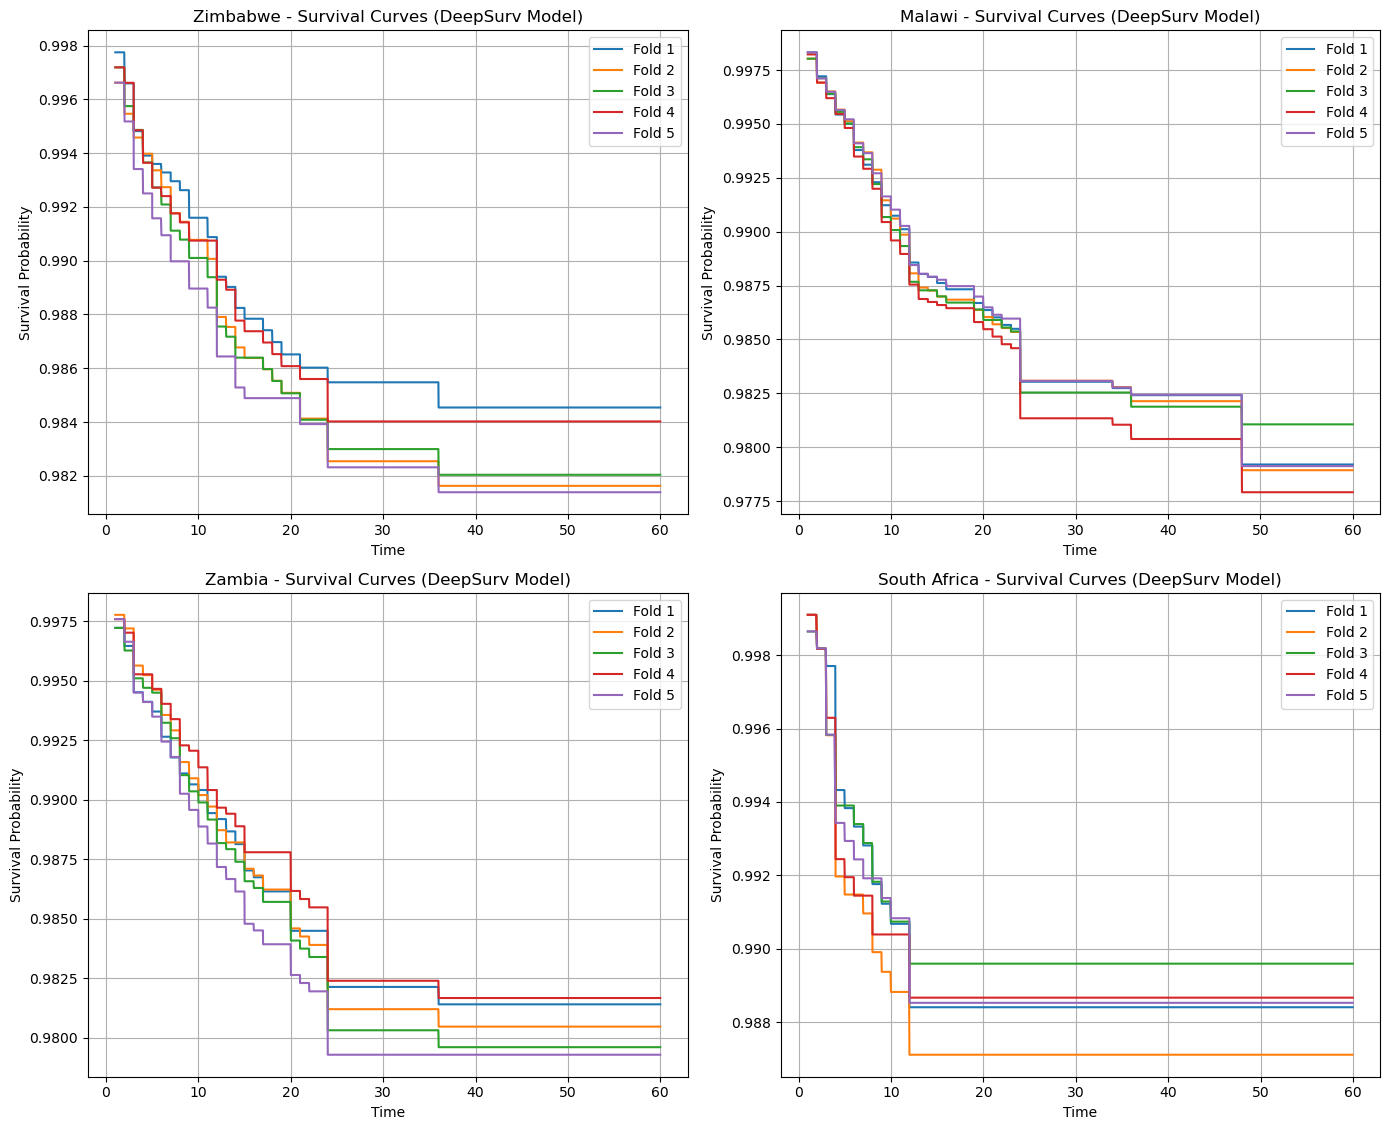

In [39]:
import matplotlib.pyplot as plt
import os

def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    """
    Plot the mean survival curves for each country in a 2x2 grid.
    
    Parameters:
    - mean_survival_curves_dict: A dictionary where keys are country names and values are lists of survival curves for each fold.
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    axs = axs.flatten()

    for i, (country, survival_curves) in enumerate(mean_survival_curves_dict.items()):
        for fold_idx, surv in enumerate(survival_curves):
            mean_surv = surv.mean(axis=1)
            axs[i].plot(surv.index, mean_surv, label=f'Fold {fold_idx + 1}')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Survival Probability')
        axs[i].set_title(f'{country} - Survival Curves (DeepSurv Model)')
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save the plot in the Plots folder
    plots_folder = "Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_path = os.path.join(plots_folder, f'Mean_Survival_Curves_DeepSurv.png')
    plt.savefig(plot_path)
    plt.show()

def fit_and_collect_survival_curves(df, duration_col, event_col, dataset_name, model_type='deepsurv', folds=5, epochs=100, lr=0.01, batch_size=64):
    
    # Prepare the data
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)  # Convert to float32
    y = (df[duration_col].values, df[event_col].values)

    # Initialize cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        # Set up the neural network and Cox model
        if model_type == 'deepsurv':
            net = SimpleMLP(in_features=x_train.shape[1])
            model = CoxPH(net, tt.optim.Adam)

        # Train the model
        log = model.fit(x_train, y_train, batch_size, epochs, callbacks=[tt.callbacks.EarlyStopping(patience=10)], val_data=(x_val, y_val), verbose=False)

        # Compute baseline hazards
        model.compute_baseline_hazards()

        # Predict survival probabilities for the validation set
        surv = model.predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    return mean_survival_curves

# Collect the survival curves for each country
mean_survival_curves_dict = {
    'Zimbabwe': fit_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

# All countries' survival curves
plot_mean_survival_curves_for_countries(mean_survival_curves_dict)


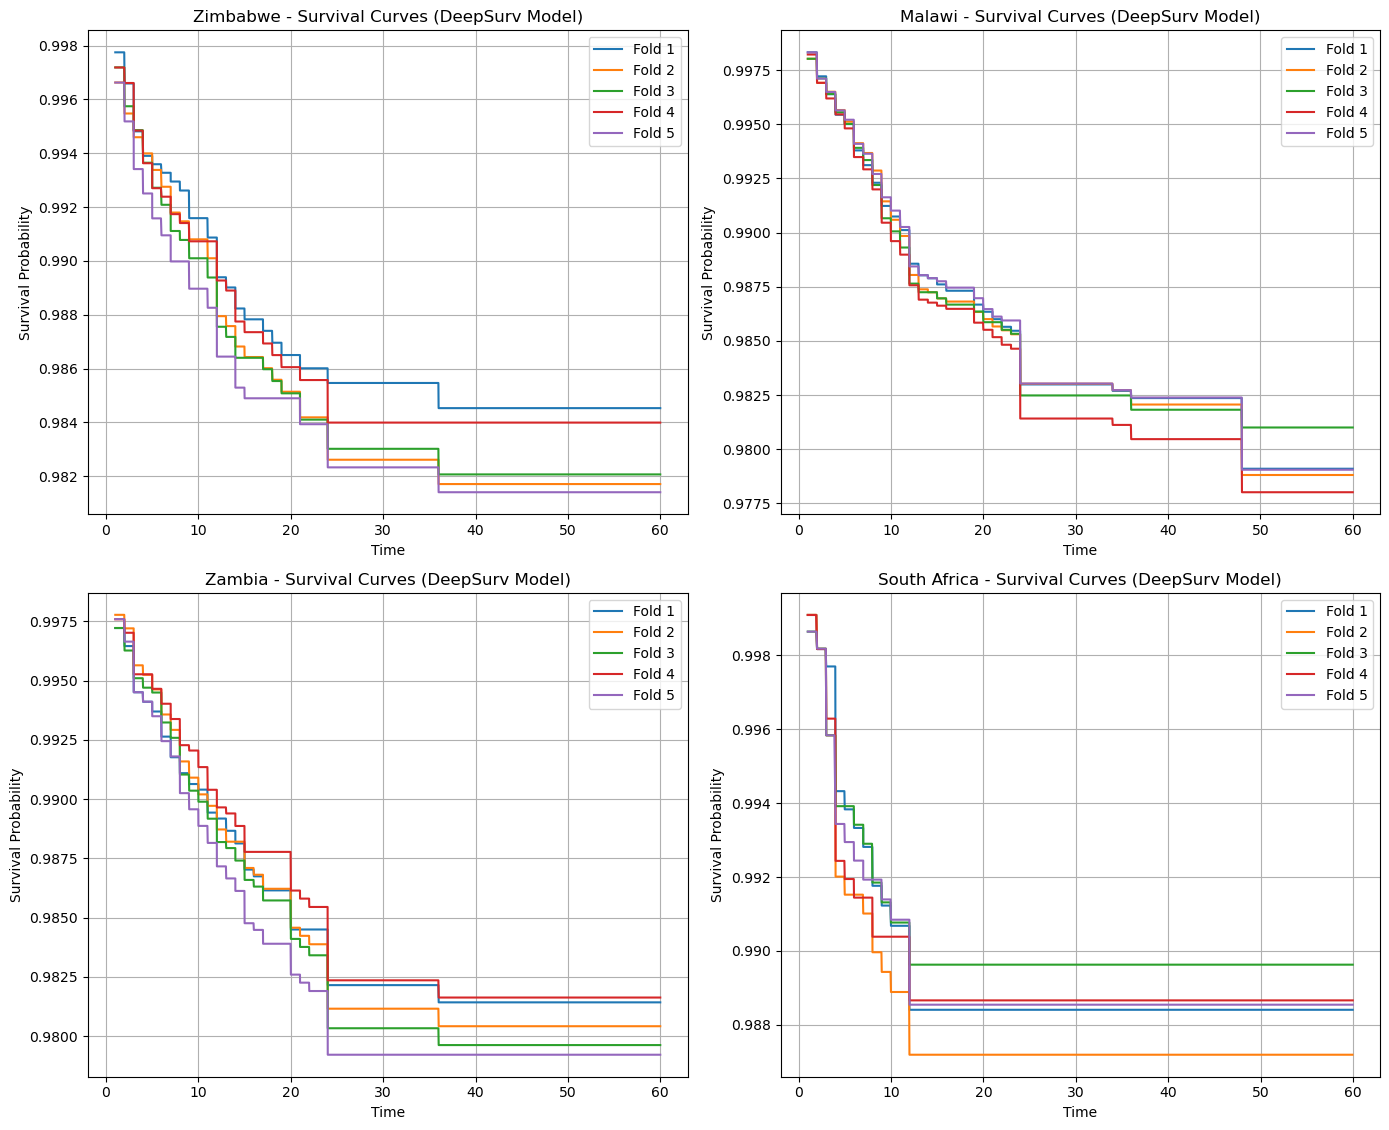

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import KFold
import torch
import torchtuples as tt
from pycox.models import CoxPH

# Define a simple MLP (feedforward network)
class SimpleMLP(torch.nn.Module):
    def __init__(self, in_features, num_nodes=256, out_features=1):
        super(SimpleMLP, self).__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_features, num_nodes),
            torch.nn.ReLU(),
            torch.nn.Linear(num_nodes, num_nodes),
            torch.nn.ReLU(),
            torch.nn.Linear(num_nodes, out_features)
        )

    def forward(self, x):
        return self.net(x)

def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    """
    Plot the mean survival curves for each country in a 2x2 grid.
    
    Parameters:
    - mean_survival_curves_dict: A dictionary where keys are country names and values are lists of survival curves for each fold.
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    axs = axs.flatten()

    for i, (country, survival_curves) in enumerate(mean_survival_curves_dict.items()):
        for fold_idx, surv in enumerate(survival_curves):
            mean_surv = surv.mean(axis=1)  # Mean across the folds
            axs[i].plot(surv.index, mean_surv, label=f'Fold {fold_idx + 1}')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Survival Probability')
        axs[i].set_title(f'{country} - Survival Curves (DeepSurv Model)')
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save the plot in the Plots folder
    plots_folder = "Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_path = os.path.join(plots_folder, f'Mean_Survival_Curves_DeepSurv.png')
    plt.savefig(plot_path)
    plt.show()

def fit_and_collect_survival_curves(df, duration_col, event_col, dataset_name, model_type='deepsurv', folds=5, epochs=100, lr=0.01, batch_size=64):
    """
    Fit a DeepSurv model and collect survival curves from cross-validation folds.
    """
    # Prepare the data
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)  # Convert to float32
    y = (df[duration_col].values, df[event_col].values)

    # Initialize cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        # Set up the neural network and Cox model
        if model_type == 'deepsurv':
            net = SimpleMLP(in_features=x_train.shape[1])
            model = CoxPH(net, tt.optim.Adam)

        # Train the model
        log = model.fit(x_train, y_train, batch_size, epochs, callbacks=[tt.callbacks.EarlyStopping(patience=10)], val_data=(x_val, y_val), verbose=False)

        # Compute baseline hazards
        model.compute_baseline_hazards()

        # Predict survival probabilities for the validation set
        surv = model.predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    return mean_survival_curves

# Collect the survival curves for each country
mean_survival_curves_dict = {
    'Zimbabwe': fit_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

# Plot all countries' survival curves in a 2x2 grid
plot_mean_survival_curves_for_countries(mean_survival_curves_dict)



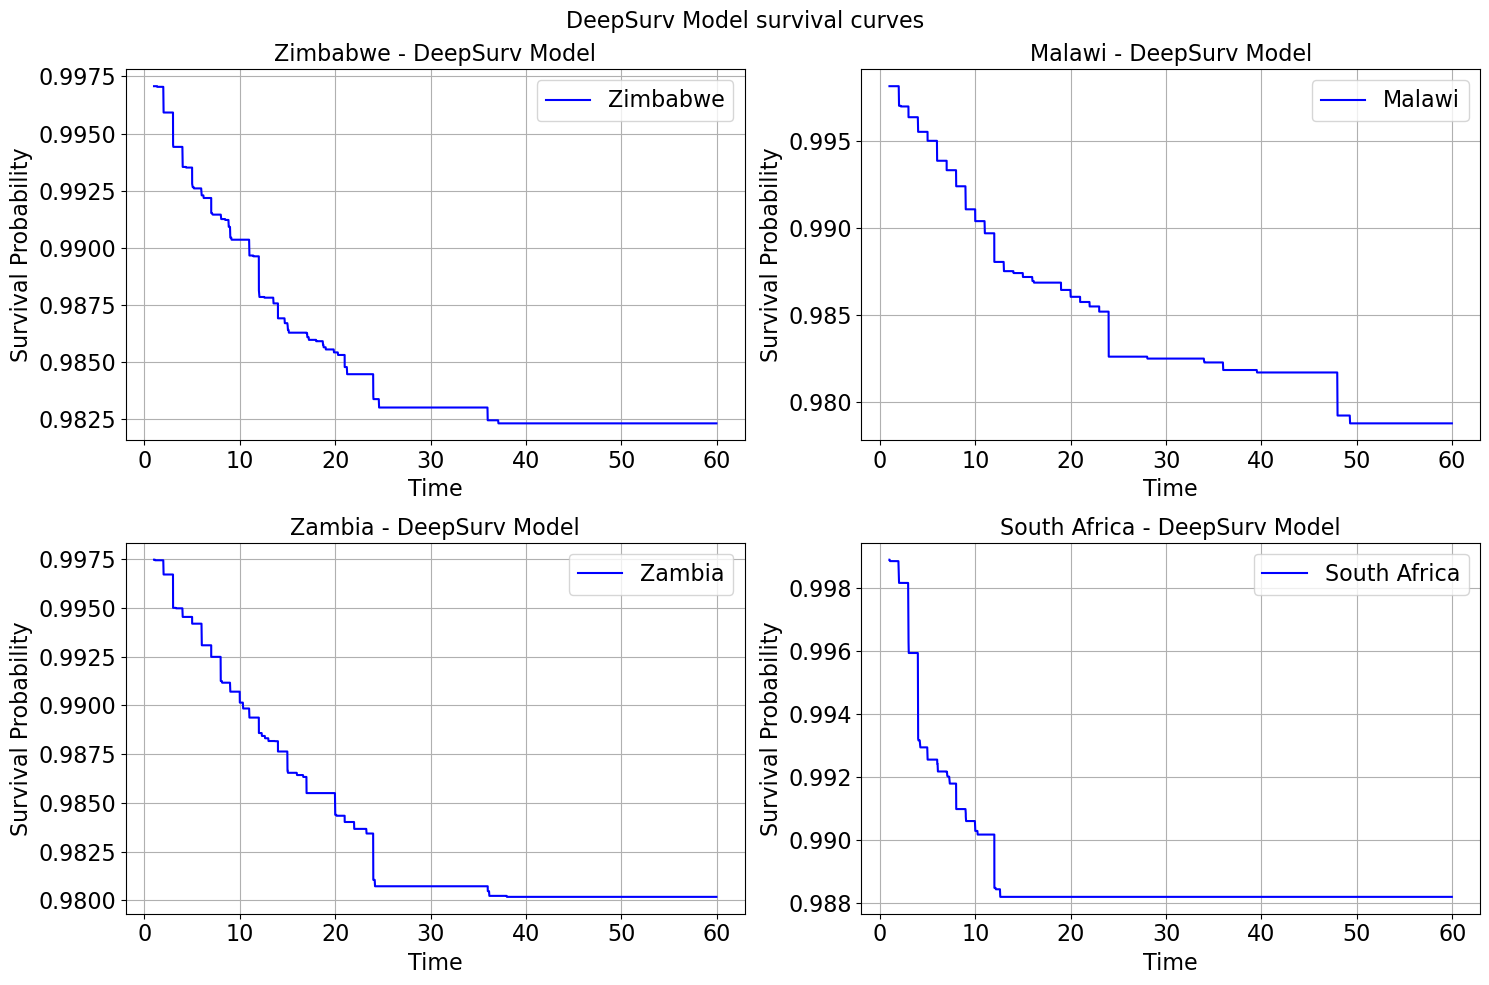

In [41]:

def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))  # Create a 2x2 grid of subplots
    axs = axs.flatten()  # Flatten the axes array for easy indexing

    for i, country in enumerate(countries):
        # Extract the survival data for the specific country
        survival_data_list = mean_survival_curves_dict[country]
        
        # Concatenate all the DataFrames into a single DataFrame along the columns axis
        concatenated_df = pd.concat(survival_data_list, axis=1)
        
        # Calculate the mean survival probabilities across all columns (axis=1) for each time point
        mean_survival_probabilities = concatenated_df.mean(axis=1)
        
        # Ensure the survival curve is monotonically decreasing
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)
        
        # Get the time (index from the first DataFrame, assuming all DataFrames have the same index)
        time_data = concatenated_df.index.values

        # Plot on the corresponding axis
        axs[i].plot(time_data, mean_survival_probabilities, label=f'{country}', color='blue')
        axs[i].set_title(f'{country} - DeepSurv Model',fontsize=16)
        axs[i].set_xlabel('Time', fontsize=16)
        axs[i].set_ylabel('Survival Probability', fontsize=16)
        axs[i].legend(fontsize=16)
        axs[i].grid(True)
        axs[i].tick_params(axis="both", labelsize=16)
    fig.suptitle('DeepSurv Model survival curves', fontsize=16)
    plt.tight_layout()
    plt.show()

# Call the function to plot for all four countries
plot_mean_survival_curves_for_countries(mean_survival_curves_dict)


Low c index poor discrimination


High brier score poor model calibration

High c index outstanding discrimination


High brier score poor model calibration

## DeepHit


In [42]:
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Define the neural network structure using PyTorch directly for DeepHit
class SimpleMLPDeepHit(nn.Module):
    def __init__(self, in_features, num_durations, num_risks=1, num_nodes=[32, 32], dropout=0.1):
        super(SimpleMLPDeepHit, self).__init__()
        layers = []
        input_size = in_features
        for nodes in num_nodes:
            layers.append(nn.Linear(input_size, nodes))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_size = nodes
        layers.append(nn.Linear(input_size, num_durations))
        self.shared_net = nn.Sequential(*layers)
        self.logits = torch.nn.ModuleList([nn.Linear(num_durations, num_durations) for _ in range(num_risks)])

    def forward(self, x):
        h = self.shared_net(x)
        return [logit(h) for logit in self.logits]

# Function to fit a DeepHit model with cross-validation and collect survival curves
def fit_deephit_model_cv(df, duration_col, event_col, dataset_name, folds=5, epochs=20, lr=0.01, batch_size=64):
    # Prepare the data
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)
    y = (df[duration_col].values, df[event_col].values)

    # Explicitly specify the time cuts to ensure they are sorted and properly aligned
    num_durations = 50  # You can adjust this number based on your data
    labtrans = DeepHitSingle.label_transform(num_durations)
    y = labtrans.fit_transform(*y)
    
    # Ensure that cuts are sorted (important to avoid the error)
    assert np.all(np.diff(labtrans.cuts) > 0), "Cuts are not sorted properly."

    # Initialize cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []

    # Set up a checkpoint path that is accessible
    checkpoint_folder = os.path.expanduser("~/Desktop/Model_Checkpoints")
    os.makedirs(checkpoint_folder, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        # Set up the neural network and DeepHit model
        net = SimpleMLPDeepHit(in_features=x_train.shape[1], num_durations=num_durations)
        model = DeepHitSingle(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

        # Train the model
        best_score = float('inf')
        for epoch in range(epochs):
            log = model.fit(x_train, y_train, batch_size, 1, val_data=(x_val, y_val), verbose=False)
            current_score = log.to_pandas()['val_loss'].values[-1]
            if current_score < best_score:
                best_score = current_score
                checkpoint_path = os.path.join(checkpoint_folder, f'best_model_fold_{fold}_epoch_{epoch + 1}.pt')
                torch.save(model.net.state_dict(), checkpoint_path)

        # Evaluate the model
        surv = model.interpolate(10).predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    return mean_survival_curves

# Collect the survival curves for each country using DeepHit
mean_survival_curves_dict_deephit = {
    'Zimbabwe': fit_deephit_model_cv(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_deephit_model_cv(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_deephit_model_cv(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_deephit_model_cv(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}




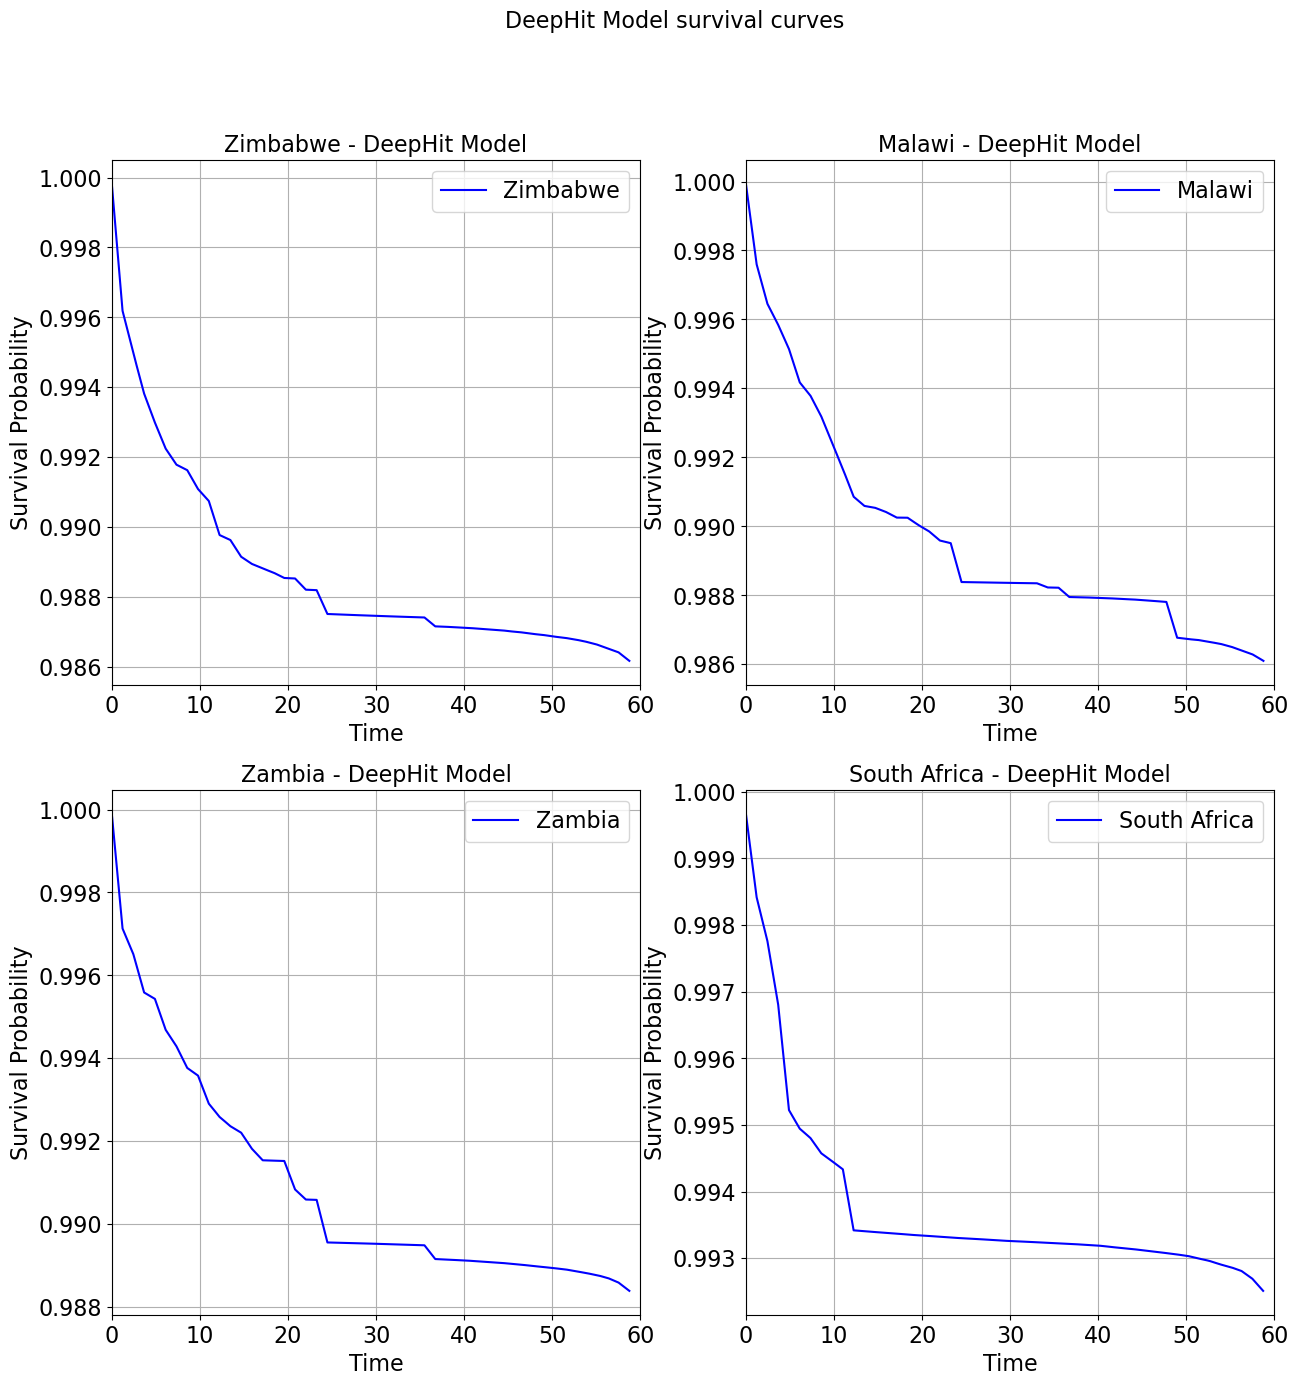

In [51]:
def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))  # Create a 2x2 grid of subplots
    axs = axs.flatten()  # Flatten the axes array for easy indexing

    for i, country in enumerate(countries):
        # Extract the survival data for the specific country
        survival_data_list = mean_survival_curves_dict[country]
        
        # Concatenate all the DataFrames into a single DataFrame along the columns axis
        concatenated_df = pd.concat(survival_data_list, axis=1)
        
        # Calculate the mean survival probabilities across all columns (axis=1) for each time point
        mean_survival_probabilities = concatenated_df.mean(axis=1)
        
        # Ensure the survival curve is monotonically decreasing
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)
        
        # Get the time (index from the first DataFrame, assuming all DataFrames have the same index)
        time_data = concatenated_df.index.values
        
        # Set a minimum threshold to prevent the sudden drop (adjust threshold as necessary)
        mean_survival_probabilities[mean_survival_probabilities < 0.97] = np.nan

        # Plot on the corresponding axis
        axs[i].plot(time_data, mean_survival_probabilities, label=f'{country}', color='blue')
        axs[i].set_title(f'{country} - DeepHit Model', fontsize=16)
        axs[i].set_xlabel('Time', fontsize=16)
        axs[i].set_ylabel('Survival Probability', fontsize=16)
        axs[i].legend(fontsize=16)
        axs[i].grid(True)
        axs[i].tick_params(axis="both", labelsize=16)
        
        # Set the x-axis limits to cut the plot at 59, but include 60 on the axis
        axs[i].set_xlim(0, 60)  # Set x-axis limits
        axs[i].set_xticks(np.arange(0, 61, 10))  # Ensure tick marks include 60
    fig.suptitle('DeepHit Model survival curves', fontsize=16)
    #plt.tight_layout()
    #plt.show()
    
    return fig, axs

# Call the function to plot for all four countries and cut the plot at 59
fig, axs = plot_mean_survival_curves_for_countries(mean_survival_curves_dict_deephit)


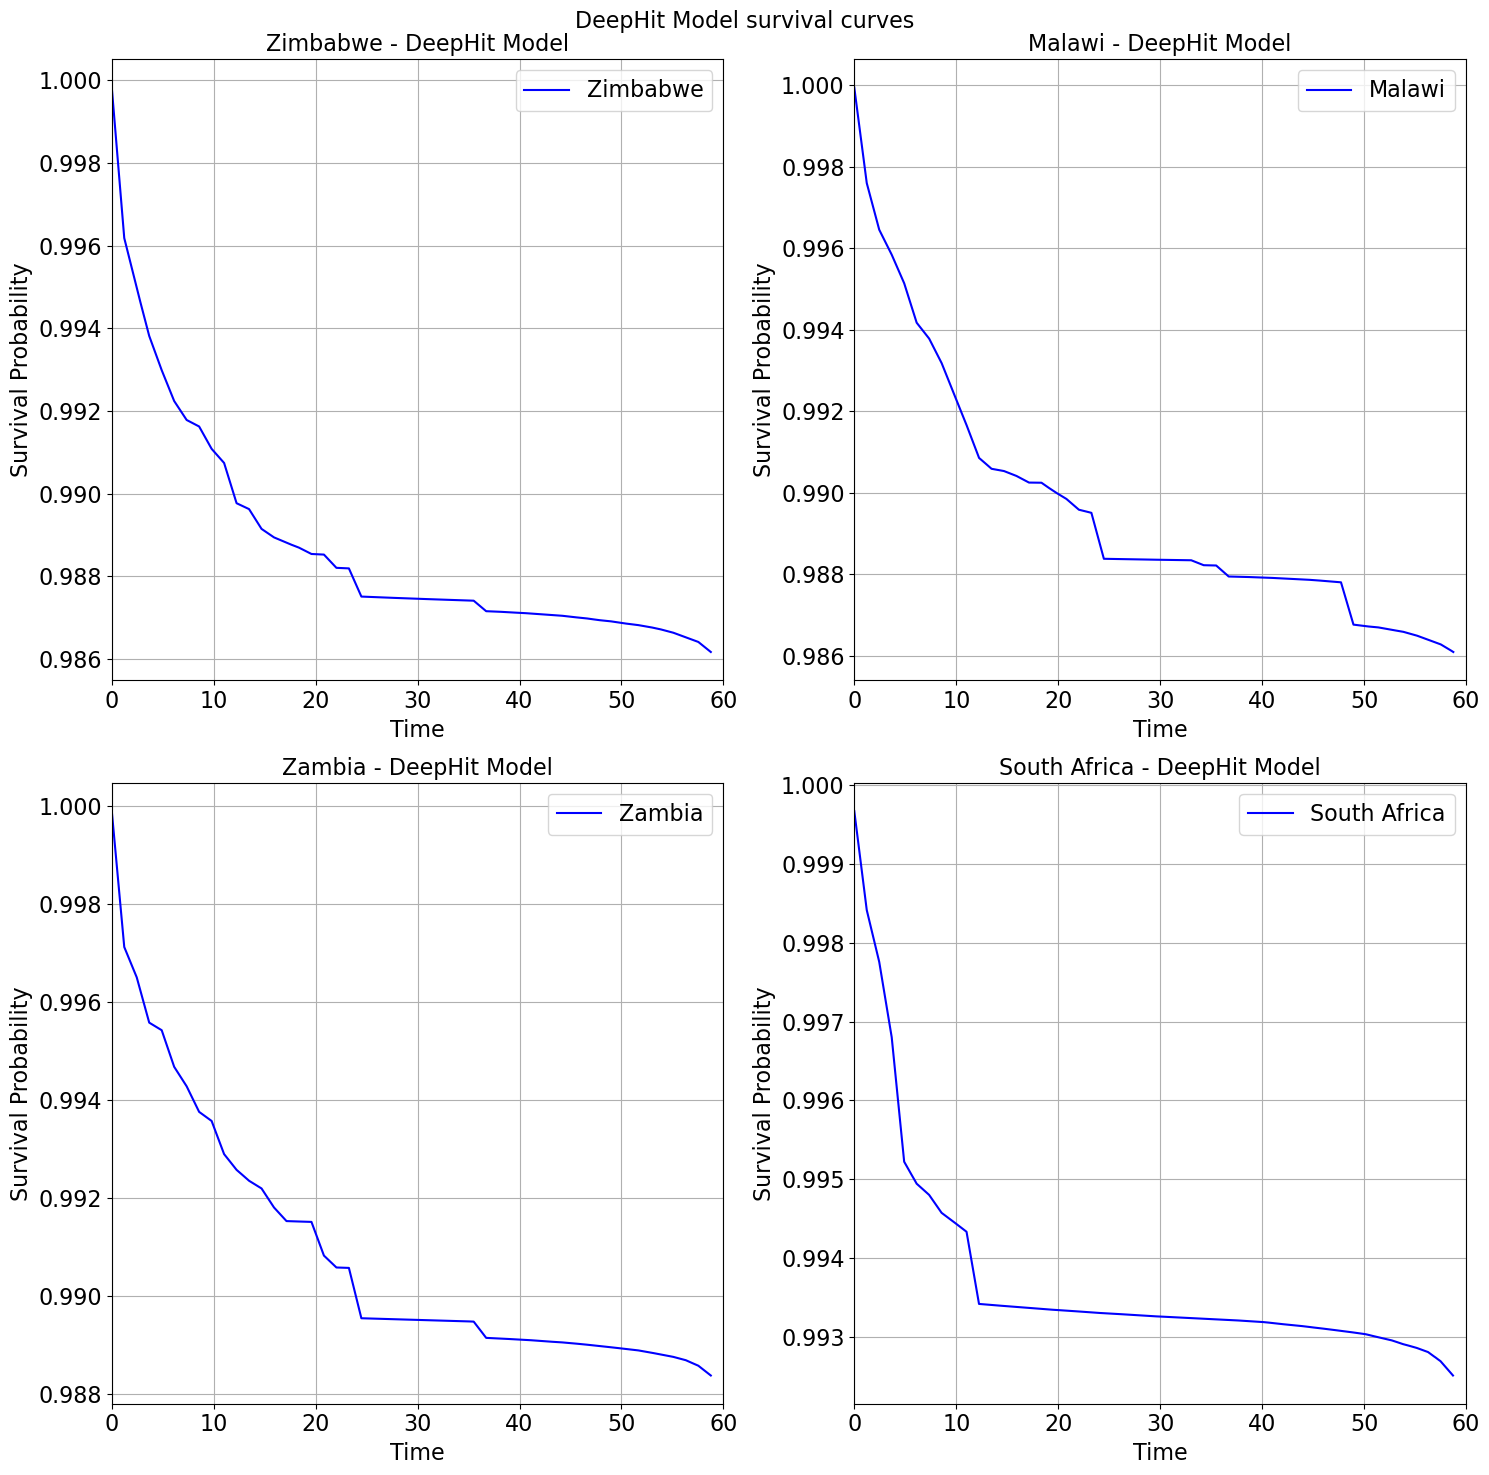

In [54]:
fig, axs = plot_mean_survival_curves_for_countries(mean_survival_curves_dict_deephit)
fig.tight_layout()
fig.savefig("plotDeephit_survProb.pdf")
plt.show()


In [55]:
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import os
from datetime import datetime
from sklearn.metrics import brier_score_loss

# Define the neural network structure using PyTorch directly for DeepHit
class SimpleMLPDeepHit(nn.Module):
    def __init__(self, in_features, num_durations, num_risks=1, num_nodes=[32, 32], dropout=0.1):
        super(SimpleMLPDeepHit, self).__init__()
        layers = []
        input_size = in_features
        for nodes in num_nodes:
            layers.append(nn.Linear(input_size, nodes))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_size = nodes
        layers.append(nn.Linear(input_size, num_durations))
        self.shared_net = nn.Sequential(*layers)
        self.logits = torch.nn.ModuleList([nn.Linear(num_durations, num_durations) for _ in range(num_risks)])

    def forward(self, x):
        h = self.shared_net(x)
        return [logit(h) for logit in self.logits]

# Function to calculate Brier score at the closest time point
def calculate_brier_score(surv, durations, events, time_point):
    # Find the closest time point manually
    closest_time_point = surv.index[(np.abs(surv.index - time_point)).argmin()]
    surv_at_time = surv.loc[closest_time_point].values
    brier = brier_score_loss(events, 1 - surv_at_time, pos_label=1)
    return brier, closest_time_point

# Function to fit a DeepHit model with cross-validation and collect survival curves
def fit_deephit_model_cv(df, duration_col, event_col, dataset_name, folds=5, epochs=100, lr=0.01, batch_size=64):
    # Prepare the data
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)
    y = (df[duration_col].values, df[event_col].values)

    # Explicitly specify the time cuts to ensure they are sorted and properly aligned
    num_durations = 50  # You can adjust this number based on your data
    labtrans = DeepHitSingle.label_transform(num_durations)
    y = labtrans.fit_transform(*y)
    
    # Ensure that cuts are sorted (important to avoid the error)
    assert np.all(np.diff(labtrans.cuts) > 0), "Cuts are not sorted properly."

    # Initialize cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []
    c_index_results = []
    brier_score_results = []

    # Set up a checkpoint path that is accessible
    checkpoint_folder = os.path.expanduser("~/Desktop/Model_Checkpoints")
    os.makedirs(checkpoint_folder, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        # Set up the neural network and DeepHit model
        net = SimpleMLPDeepHit(in_features=x_train.shape[1], num_durations=num_durations).to(device)
        model = DeepHitSingle(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

        # Train the model
        best_score = float('inf')
        for epoch in range(epochs):
            log = model.fit(x_train, y_train, batch_size, 1, val_data=(x_val, y_val), verbose=False)
            current_score = log.to_pandas()['val_loss'].values[-1]
            if current_score < best_score:
                best_score = current_score
                checkpoint_path = os.path.join(checkpoint_folder, f'best_model_fold_{fold}_epoch_{epoch + 1}.pt')
                torch.save(model.net.state_dict(), checkpoint_path)

        # Evaluate the model
        surv = model.interpolate(10).predict_surv_df(x_val)
        mean_survival_curves.append(surv)

        # Calculate C-index
        ev = EvalSurv(surv, y_val[0], y_val[1], censor_surv='km')
        c_index = ev.concordance_td('antolini')
        c_index_results.append(c_index)

        # Calculate Brier score at the closest time point
        time_point = surv.index.values[-1] * 0.5  # Using the midpoint as an example
        brier_score, closest_time_point = calculate_brier_score(surv, y_val[0], y_val[1], time_point)
        brier_score_results.append(brier_score)

        print(f'{dataset_name} - Fold {fold} C-index: {c_index}, Brier score at time {closest_time_point:.2f}: {brier_score}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results)
    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')

    return mean_survival_curves, mean_c_index, mean_brier_score

# Use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect the survival curves, C-index, and Brier scores for each country using DeepHit
mean_survival_curves_dict_deephit, c_index_dict_deephit, brier_score_dict_deephit = {}, {}, {}

for country, df in zip(['Zimbabwe', 'Malawi', 'Zambia', 'South Africa'], 
                       [zimbabwe_selected_df, malawi_selected_df, zambia_selected_df, sa_selected_df]):
    mean_survival_curves, mean_c_index, mean_brier_score = fit_deephit_model_cv(df, 'survival_time', 'Status_1', country)
    mean_survival_curves_dict_deephit[country] = mean_survival_curves
    c_index_dict_deephit[country] = mean_c_index
    brier_score_dict_deephit[country] = mean_brier_score



Zimbabwe - Fold 1 C-index: 0.7972852692478861, Brier score at time 30.00: 0.0169293064290227
Zimbabwe - Fold 2 C-index: 0.7957030747459154, Brier score at time 30.00: 0.013764947988750184
Zimbabwe - Fold 3 C-index: 0.6596745027124774, Brier score at time 30.00: 0.014746700736160556
Zimbabwe - Fold 4 C-index: 0.34042357274401475, Brier score at time 30.00: 0.013459912821549526
Zimbabwe - Fold 5 C-index: 0.9661647146309723, Brier score at time 30.00: 0.007816126086223351
Zimbabwe - Mean C-index over 5 folds: 0.7118502268162532
Zimbabwe - Mean Brier score over 5 folds: 0.013343398812341265
Malawi - Fold 1 C-index: 0.899708968369457, Brier score at time 30.00: 0.007932099504833682
Malawi - Fold 2 C-index: 0.899850827230811, Brier score at time 30.00: 0.010312011372950163
Malawi - Fold 3 C-index: 0.7169955817378498, Brier score at time 30.00: 0.011009140362754457
Malawi - Fold 4 C-index: 0.9416569215027043, Brier score at time 30.00: 0.0076990086693812165
Malawi - Fold 5 C-index: 0.96219734

In [57]:
zimbabwe_data = {
    'C-index': [0.7837116154873164, 0.7967322783995883, 0.9537070524412297, 0.5231123388581952, 0.9442275515895148],
    'Brier score at time 30.00': [0.019217118705703303, 0.012085382317718487, 0.01473819240682827, 0.016061461679027722, 0.008049487636225634]
}

malawi_data = {
    'C-index': [0.9405427484618724, 0.8505966910767562, 0.8787334315169367, 0.9189263265604444, 0.8824672460450866],
    'Brier score at time 30.00': [0.00960757586423813, 0.011378285420248912, 0.010627159759662153, 0.009859205583968208, 0.010308629494700752]
}

zambia_data = {
    'C-index': [0.8623002648893446, 0.7735261496459347, 0.5907140917730112, 0.918667093424375, 0.9224500300248778],
    'Brier score at time 30.00': [0.01320520670991109, 0.01167579808013511, 0.011310667463962332, 0.010588847213816695, 0.008460540234565841]
}

south_africa_data = {
    'C-index': [0.32358550540368725, 0.7074504442925496, 0.6273451554870213, 0.46393897364771153, 0.8221701272605493],
    'Brier score at time 29.98': [0.011258339968299785, 0.0036747204161247105, 0.011556839980131652, 0.007437731115359132, 0.008536862715382204]
}

# Create DataFrames for each country's data
df_zimbabwe = pd.DataFrame(zimbabwe_data)
df_malawi = pd.DataFrame(malawi_data)
df_zambia = pd.DataFrame(zambia_data)
df_south_africa = pd.DataFrame(south_africa_data)

# Write the DataFrames to CSV files for each country
df_zimbabwe.to_csv('Zimbabwe_Cindex_BrierScore_DeepHit.csv', index=False)
df_malawi.to_csv('Malawi_Cindex_BrierScore_DeepHit.csv', index=False)
df_zambia.to_csv('Zambia_Cindex_BrierScore_DeepHit.csv', index=False)
df_south_africa.to_csv('South_Africa_Cindex_BrierScore_DeepHit.csv', index=False)

Great model discrimination

Great model calibration

## Random Survival Model

In [58]:

from sklearn.model_selection import KFold
from sksurv.ensemble import RandomSurvivalForest

In [59]:
def fit_rsf_model_cv(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    # Prepare the data
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Fit the Random Survival Forest model
        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
        rsf.fit(X_train, y_train)

        # Compute time points from rsf.event_times_
        time_points = np.percentile(rsf.event_times_, [25, 50, 75])

        # Calculate C-index
        c_index = rsf.score(X_val, y_val)
        c_index_results.append(c_index)

        # Calculate Brier score at specific time points
        brier_scores = []
        surv_prob = rsf.predict_survival_function(X_val)

        # Get the time range for the survival functions
        surv_times = surv_prob[0].x
        min_time = surv_times[0]
        max_time = surv_times[-1]

        # Ensure time points are within the valid time range
        time_points = np.clip(time_points, min_time, max_time)

        for time_point in time_points:
            # Evaluate survival probabilities at the given time_point
            surv_prob_at_time = np.array([fn(time_point) for fn in surv_prob])
            # Compute Brier score
            brier_score_val = brier_score(y_train, y_val, surv_prob_at_time.reshape(-1, 1), times=[time_point])
            brier_scores.append(brier_score_val[1].mean())  # [1] contains the Brier scores for each time point
        brier_score_results.append(np.mean(brier_scores))

        print(f'{dataset_name} - Fold {fold + 1} C-index: {c_index}, Brier score: {np.mean(brier_scores)}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results)
    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')

    return mean_c_index, mean_brier_score
# Fit RSF for each dataset
mean_c_index_zimbabwe, mean_brier_zimbabwe = fit_rsf_model_cv(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe')
mean_c_index_malawi, mean_brier_malawi = fit_rsf_model_cv(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi')
mean_c_index_zambia, mean_brier_zambia = fit_rsf_model_cv(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia')
mean_c_index_sa, mean_brier_sa = fit_rsf_model_cv(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')

# Summary of results
print("\nSummary of Random Survival Forest Model Results:")
print(f"Zimbabwe - Mean C-index: {mean_c_index_zimbabwe}, Mean Brier score: {mean_brier_zimbabwe}")
print(f"Malawi - Mean C-index: {mean_c_index_malawi}, Mean Brier score: {mean_brier_malawi}")
print(f"Zambia - Mean C-index: {mean_c_index_zambia}, Mean Brier score: {mean_brier_zambia}")
print(f"South Africa - Mean C-index: {mean_c_index_sa}, Mean Brier score: {mean_brier_sa}")


NameError: name 'brier_score' is not defined

In [60]:
import pandas as pd
zimbabwe_data = {
    'C-index': [0.9178704993766957, 0.8143433324930678, 0.918289786223278, 0.8876322510032835, 0.9108910891089109],
    'Brier score': [0.013910187012959494, 0.010483135929762718, 0.008920516346083483, 0.010954205112846935, 0.004094966338874431]
}

malawi_data = {
    'C-index': [0.9678835606098727, 0.9355132184523173, 0.9477891255150003, 0.9252196503635282, 0.9527473820449465],
    'Brier score': [0.01042144369133561, 0.009951050883715493, 0.008364721283847432, 0.008017468562640661, 0.010943217413375098]
}

zambia_data = {
    'C-index': [0.9746457553714838, 0.937035472972973, 0.9133219470538002, 0.9281479142546398, 0.9150343424065124],
    'Brier score': [0.009138443170549765, 0.010955980928640847, 0.009311997971053943, 0.01395895754759849, 0.004801758959561113]
}

south_africa_data = {
    'C-index': [0.9154885328306629, 0.9441797140912185, 0.820538891713269, 0.9545920109252305, 0.9535420098846787],
    'Brier score': [0.01027830488974423, 0.0029832970556284994, 0.008109467613073174, 0.0029820712651275876, 0.006685641809782261]
}

# Create DataFrames for each country's data
df_zimbabwe = pd.DataFrame(zimbabwe_data)
df_malawi = pd.DataFrame(malawi_data)
df_zambia = pd.DataFrame(zambia_data)
df_south_africa = pd.DataFrame(south_africa_data)

# Write the DataFrames to CSV files for each country
df_zimbabwe.to_csv('Zimbabwe_Cindex_BrierScoreRSF.csv', index=False)
df_malawi.to_csv('Malawi_Cindex_BrierScoreRSF.csv', index=False)
df_zambia.to_csv('Zambia_Cindex_BrierScoreRSF.csv', index=False)
df_south_africa.to_csv('South_Africa_Cindex_BrierScoreRSF.csv', index=False)

Great model discrimination

Great model calibration

ValueError: x must be within [1.000000; 12.000000]

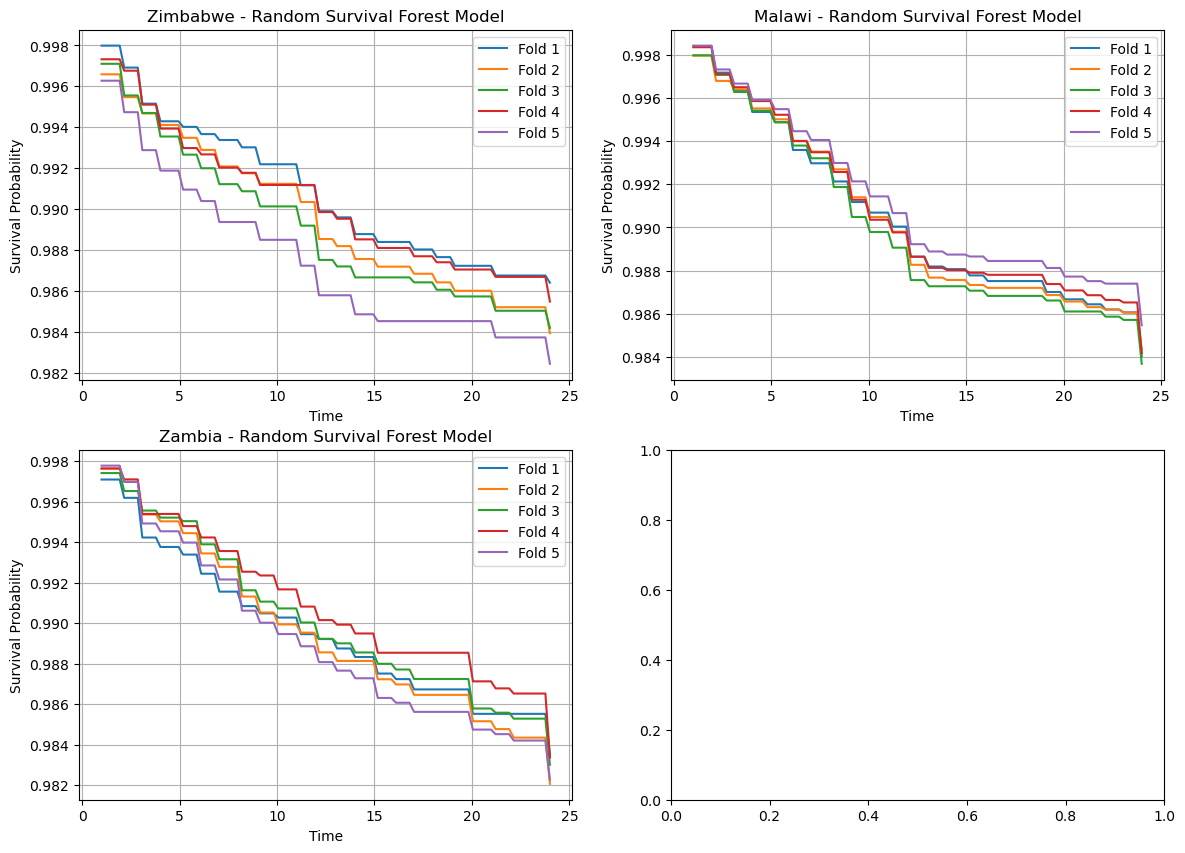

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import KFold
from datetime import datetime

# Function to plot the mean survival curves for Random Survival Forest
def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    time_grid = np.linspace(1, 24, 100)
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        for fold_idx, surv in enumerate(surv_curves):
            times = surv[0].x  # Extract the times from the StepFunction
            survival_probs = np.mean([fn(time_grid) for fn in surv], axis=0)
            axes[i].plot(time_grid, survival_probs, label=f'Fold {fold_idx + 1}')
        
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    plt.tight_layout()
    
    # Save the plot
    plots_folder = "C:/Users/cyrch/OneDrive - University of Witwatersrand/Desktop_hp/Side Projects/Mafa/Zim_Malawi_New/Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_file_path = os.path.join(plots_folder, f'RSF_Survival_Plots_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.png')
    plt.savefig(plot_file_path)
    plt.show()

# Function to fit RSF model and collect survival curves for plotting
def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    # Prepare the data
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()], dtype=[('event', 'bool'), ('time', 'float')])

    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # Cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Fit the Random Survival Forest model
        rsf = RandomSurvivalForest(n_estimators=n_estimators, min_samples_split=10, min_samples_leaf=15, max_features="sqrt", n_jobs=-1, random_state=42)
        rsf.fit(X_train, y_train)
        
        # Collect the survival curves for the validation set
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves

# Collect the survival curves for each dataset using RSF
surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

# Plot all countries' survival curves in a 2x2 grid for RSF
plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')


In [110]:
#surv_curves_dict_rsf

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime

# Function to plot the mean survival curves for Random Survival Forest
def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        # Collect all survival functions for the country
        all_surv_funcs = []
        all_times = []
        for surv_prob in surv_curves:
            # Each surv_prob is an array of StepFunctions for the validation set in a fold
            all_surv_funcs.extend(surv_prob)
            # Collect time points from all survival functions
            for fn in surv_prob:
                all_times.extend(fn.x)
        
        # Define a common set of time points
        min_time = min(all_times)
        max_time = max(all_times)
        common_times = np.linspace(min_time, max_time, 100)
        
        # Evaluate all survival functions at the common time points
        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(common_times)))
        for idx, fn in enumerate(all_surv_funcs):
            # Clip common_times to the domain of the function
            valid_times = np.clip(common_times, fn.x[0], fn.x[-1])
            surv_probs_matrix[idx, :] = fn(valid_times)
        
        # Compute the mean survival probability at each time point
        mean_surv_probs = np.mean(surv_probs_matrix, axis=0)
        
        # Plot the mean survival curve
        axes[i].plot(common_times, mean_surv_probs, label=f'Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}', fontsize=16)
        axes[i].set_xlabel('Time', fontsize=16)
        axes[i].set_ylabel('Survival Probability', fontsize=16)
        axs[i].tick_params(axis="both", labelsize=16)
        axes[i].legend(loc='best',fontsize=16)
        axes[i].grid(True)
    
    #plt.tight_layout()
    fig.suptitle('Random Survival Forest Model survival curves', fontsize=16)
    plt.show()

# Function to fit RSF model and collect survival curves for plotting
def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    # Prepare the data
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # Cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Fit the Random Survival Forest model
        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold  # Use different random_state for each fold
        )
        rsf.fit(X_train, y_train)
        
        # Collect the survival curves for the validation set
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves

# Collect the survival curves for each dataset using RSF
surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

# Plot all countries' mean survival curves in a 2x2 grid for RSF
plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')




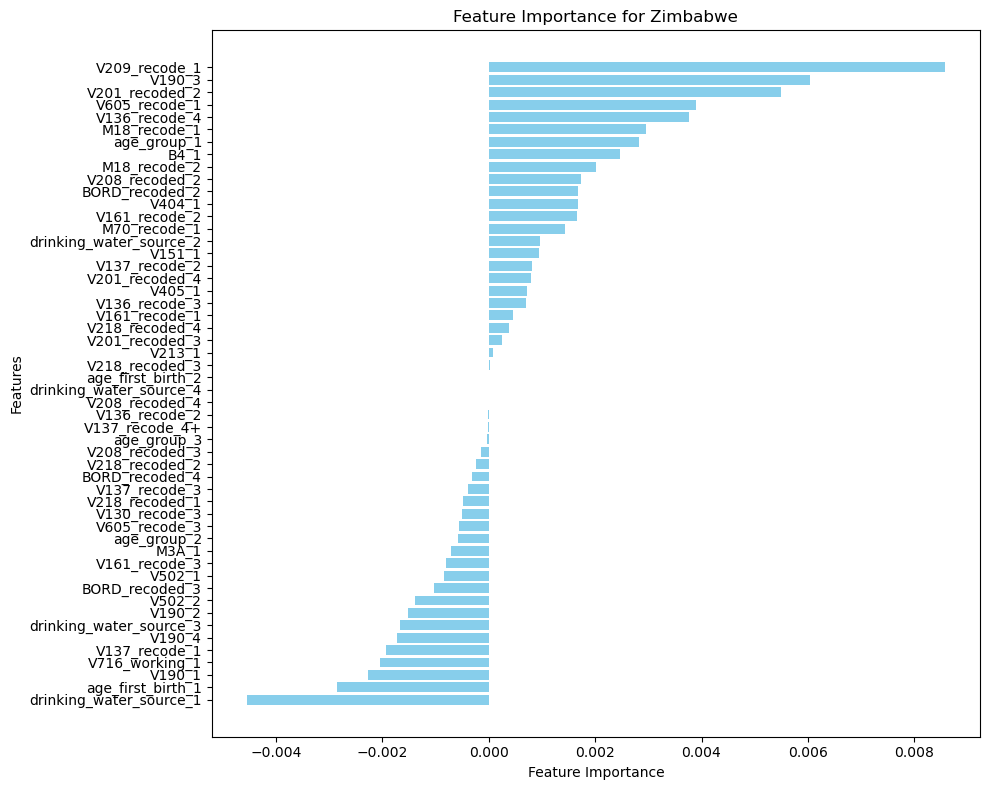

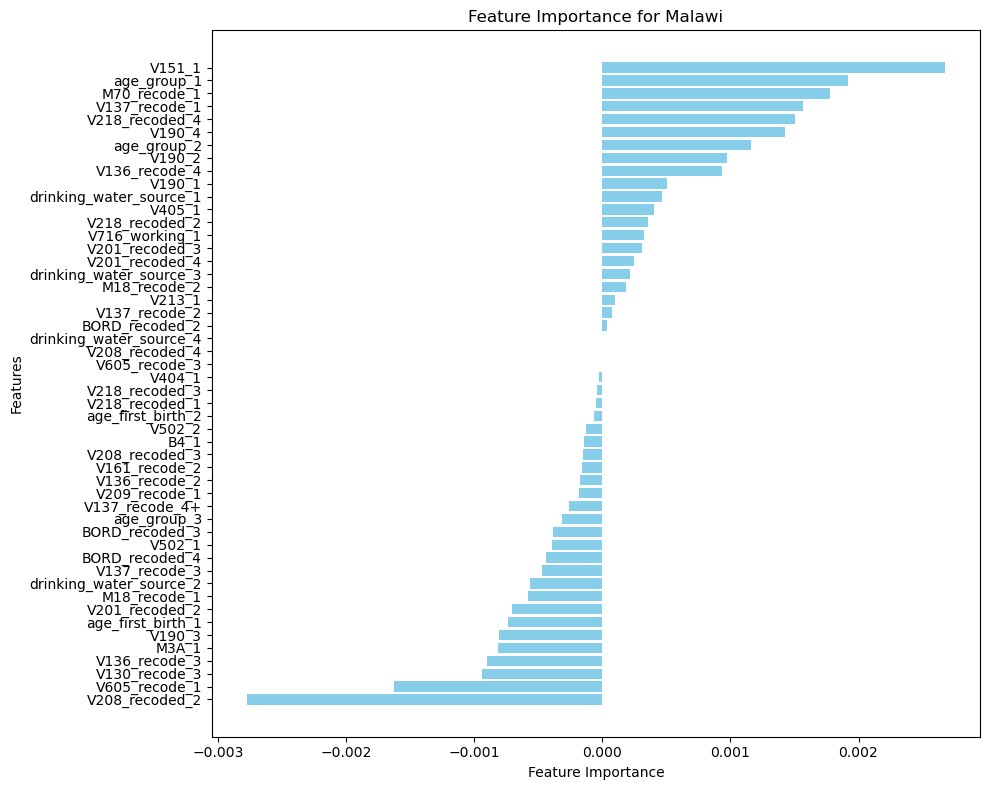

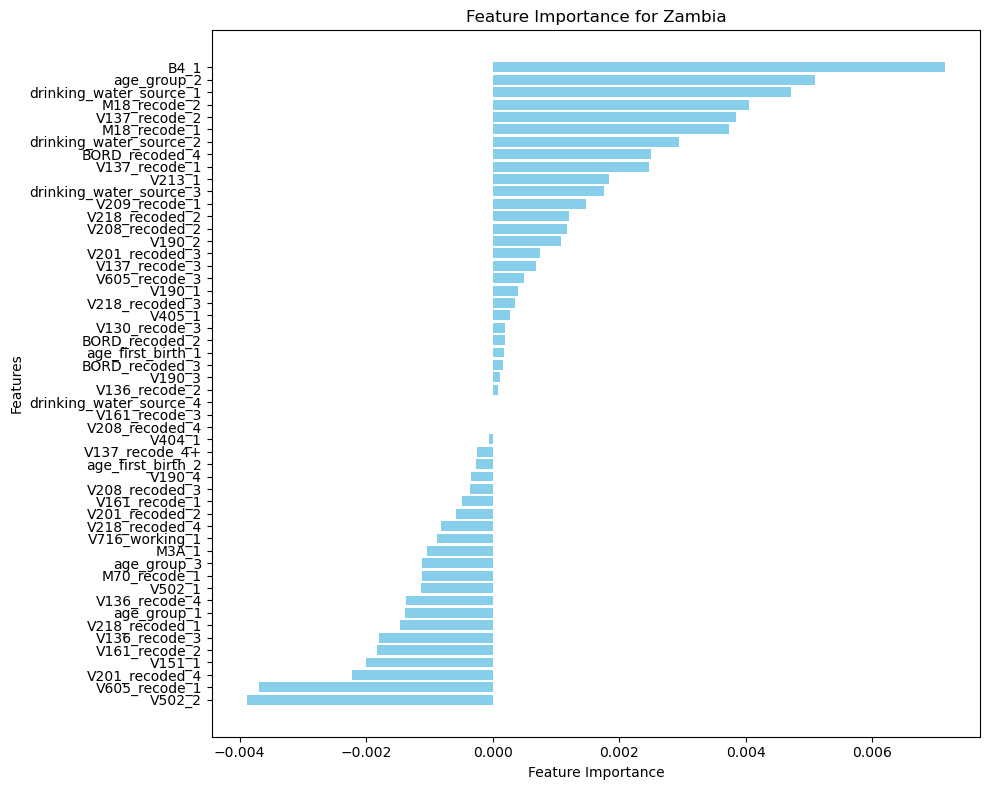

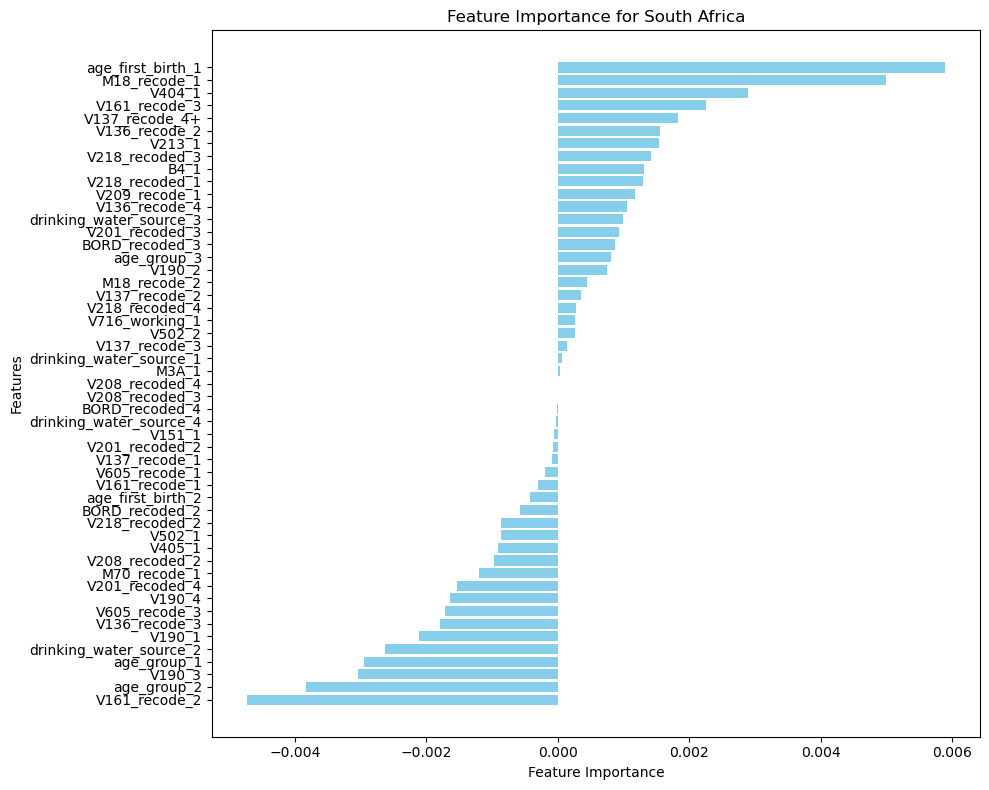

In [62]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# Function to calculate permutation importance
def permutation_importance(rsf, X_val, y_val, baseline_cindex):
    importance_scores = np.zeros(X_val.shape[1])
    for col in range(X_val.shape[1]):
        X_val_permuted = X_val.copy()
        np.random.shuffle(X_val_permuted[:, col])  # Shuffle one feature at a time
        cindex_permuted = rsf.score(X_val_permuted, y_val)
        importance_scores[col] = baseline_cindex - cindex_permuted
    return importance_scores

def fit_rsf_model_cv(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    # Prepare the data
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Initialize a list to store feature importances
    feature_importance_results = np.zeros(X.shape[1])

    # Cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Fit the Random Survival Forest model
        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
        rsf.fit(X_train, y_train)

        # Calculate baseline C-index
        baseline_cindex = rsf.score(X_val, y_val)

        # Calculate permutation importance for all features
        importance_scores = permutation_importance(rsf, X_val, y_val, baseline_cindex)
        feature_importance_results += importance_scores

    # Compute average feature importances over the folds
    feature_importance_results /= folds

    # Create a DataFrame for feature importance (all features)
    feature_importance_df = pd.DataFrame({
        'Feature': df.drop(columns=[duration_col, event_col]).columns,
        'Importance': feature_importance_results
    })

    # Sort by importance (without filtering out zero or negative values)
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    return feature_importance_df

# Example datasets with survival_time and Status_1 added
for dataset_name, df in [('Zimbabwe', zimbabwe_selected_df), ('Malawi', malawi_selected_df),
                         ('Zambia', zambia_selected_df), ('South Africa', sa_selected_df)]:
    df['survival_time'] = np.random.randint(1, 1000, size=len(df))  # Replace with actual survival time data
    df['Status_1'] = np.random.randint(0, 2, size=len(df))          # Replace with actual event status (0 or 1)

# List of datasets and names
datasets = [
    ('Zimbabwe', zimbabwe_selected_df),
    ('Malawi', malawi_selected_df),
    ('Zambia', zambia_selected_df),
    ('South Africa', sa_selected_df)
]

# Iterate over each dataset, fit the model, and plot the feature importance
for dataset_name, df in datasets:
    feature_importance_df = fit_rsf_model_cv(df, 'survival_time', 'Status_1', dataset_name)
    
    # Plotting the feature importance for each dataset (keep all features)
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel('Feature Importance')
    plt.ylabel('Features')
    plt.title(f'Feature Importance for {dataset_name}')
    plt.gca().invert_yaxis()  # Invert y-axis to show the largest importance at the top
    plt.tight_layout()
    plt.show()


In [63]:
zimbabwe_selected_df.shape
#malawi_selected_df
#zambia_selected_df
#sa_selected_df


(4436, 54)

In [64]:
# Print the column names of each dataset
for dataset_name, df in datasets:
    print(f"Columns for {dataset_name}: {df.columns}")


Columns for Zimbabwe: Index(['survival_time', 'B4_1', 'age_group_1', 'age_group_2', 'age_group_3',
       'age_first_birth_1', 'age_first_birth_2', 'drinking_water_source_1',
       'drinking_water_source_2', 'drinking_water_source_3',
       'drinking_water_source_4', 'BORD_recoded_2', 'BORD_recoded_3',
       'BORD_recoded_4', 'V208_recoded_2', 'V208_recoded_3', 'V208_recoded_4',
       'V404_1', 'V213_1', 'V405_1', 'V218_recoded_1', 'V218_recoded_2',
       'V218_recoded_3', 'V218_recoded_4', 'V502_1', 'V502_2', 'V190_1',
       'V190_2', 'V190_3', 'V190_4', 'V201_recoded_2', 'V201_recoded_3',
       'V201_recoded_4', 'V605_recode_1', 'V605_recode_3', 'V130_recode_3',
       'M70_recode_1', 'M3A_1', 'V161_recode_1', 'V161_recode_2',
       'V161_recode_3', 'V137_recode_1', 'V137_recode_2', 'V137_recode_3',
       'V137_recode_4+', 'V716_working_1', 'V136_recode_2', 'V136_recode_3',
       'V136_recode_4', 'V209_recode_1', 'M18_recode_1', 'M18_recode_2',
       'V151_1', 'Status_1'],

## COX Model

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from lifelines import CoxPHFitter
from sklearn.model_selection import KFold

# Function to plot the mean survival curves for Cox Model
def plot_mean_survival_curves_cox(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        for fold_idx, surv in enumerate(surv_curves):
            axes[i].plot(surv.index, surv.values.mean(axis=1), label=f'Fold {fold_idx + 1}')
        
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    fig.suptitle('Cox Model survival curves', fontsize=16)
    plt.show()

# Function to fit Cox model and collect survival curves for plotting
def fit_cox_and_collect_survival_curves(df, duration_col, event_col, dataset_name, folds=5):
    surv_curves = []
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]
        
        # Fit the Cox model
        cph = CoxPHFitter()
        cph.fit(train_data, duration_col=duration_col, event_col=event_col)
        
        # Collect the survival curves for the validation set
        surv_prob = cph.predict_survival_function(val_data)
        surv_curves.append(surv_prob)
    
    return surv_curves

# Collect the survival curves for each dataset using Cox model
surv_curves_dict_cox = {
    'Zimbabwe': fit_cox_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_cox_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_cox_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_cox_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

# Plot all countries' survival curves in a 2x2 grid for Cox model
plot_mean_survival_curves_cox(surv_curves_dict_cox, 'Cox Proportional Hazards Model')


/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/lifelines/utils/__init__.py:1115: ConvergenceWarning: Column V137_recode_3 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['Status_1'].astype(bool)
>>> print(df.loc[events, 'V137_recode_3'].var())
>>> print(df.loc[~events, 'V137_recode_3'].var())

A very low variance means that the column V137_recode_3 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

In [120]:
import numpy as np
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import KFold
from sklearn.metrics import brier_score_loss

# Function to calculate the Brier score
def calculate_brier_score_cph(surv, durations, events, time_point):
    closest_time_point = surv.index[np.abs(surv.index - time_point).argmin()]
    surv_at_time = surv.loc[closest_time_point].values
    brier = brier_score_loss(events, 1 - surv_at_time, pos_label=1)
    return brier, closest_time_point

# Function to fit Cox model, calculate C-index and Brier Score, and collect survival curves
def fit_cox_model_cv(df, duration_col, event_col, dataset_name, folds=5):
    # Ensure categorical variables are converted to numeric values
    df = df.copy()
    for col in df.select_dtypes(include=['category', 'object']).columns:
        df[col] = df[col].astype('category').cat.codes

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]
        
        # Fit the Cox model
        cph = CoxPHFitter()
        cph.fit(train_data, duration_col=duration_col, event_col=event_col)
        
        # Calculate C-index
        c_index = cph.concordance_index_
        c_index_results.append(c_index)
        
        # Predict survival function and calculate Brier score
        surv = cph.predict_survival_function(val_data)
        time_point = surv.index.values[-1] * 0.5  # Using the midpoint as an example
        brier_score_val, closest_time_point = calculate_brier_score_cph(surv, val_data[duration_col], val_data[event_col], time_point)
        brier_score_results.append(brier_score_val)
        
        print(f'{dataset_name} - Fold {fold + 1} C-index: {c_index}, Brier score at time {closest_time_point:.2f}: {brier_score_val}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results)
    
    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')
    
    return mean_c_index, mean_brier_score

# Calculate the C-index and Brier scores for each dataset using Cox model
for country, df in zip(['Zimbabwe', 'Malawi', 'Zambia', 'South Africa'], 
                       [zimbabwe_selected_df, malawi_selected_df, zambia_selected_df, sa_selected_df]):
    mean_c_index, mean_brier_score = fit_cox_model_cv(df, 'survival_time', 'Status_1', country)


/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/lifelines/utils/__init__.py:1115: ConvergenceWarning: Column V137_recode_3 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['Status_1'].astype(bool)
>>> print(df.loc[events, 'V137_recode_3'].var())
>>> print(df.loc[~events, 'V137_recode_3'].var())

A very low variance means that the column V137_recode_3 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

Great model discrimination

Great model calibration

## COX with Frailty

Use V209 as the group




In [121]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss

# Function to check and remove highly correlated columns
def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    print(f"Removing highly correlated columns: {to_drop}")
    df = df.drop(columns=to_drop)
    return df

# Function to handle NaN values
def handle_nans(df):
    return df.dropna()  # Option to impute or drop NaNs

# Function to calculate Brier score
def calculate_brier_score_cph(surv, durations, events, time_point):
    closest_time_point = surv.index[np.abs(surv.index - time_point).argmin()]
    surv_at_time = surv.loc[closest_time_point].values
    brier = brier_score_loss(events, 1 - surv_at_time, pos_label=1)
    return brier, closest_time_point

# Function to fit Cox model with cross-validation and calculate C-index and Brier score
def fit_cox_model_cv(df, duration_col, event_col, strata_col, dataset_name, folds=5):
    df = df.copy()

    # Handle missing values
    df = handle_nans(df)

    # Check and remove highly correlated columns
    df = remove_highly_correlated(df)

    # Standardize the data to handle scaling issues
    scaler = StandardScaler()
    scaled_columns = df.select_dtypes(include=[np.number]).columns
    df[scaled_columns] = scaler.fit_transform(df[scaled_columns])

    # Convert strata column to categorical
    if strata_col in df.columns:
        df[strata_col] = df[strata_col].astype('category')
    else:
        print(f"Column {strata_col} not found in dataset {dataset_name}.")
        return

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]

        try:
            # Fit the Cox model
            cph = CoxPHFitter(penalizer=0.1)  # Using penalizer to improve convergence
            cph.fit(train_data, duration_col=duration_col, event_col=event_col, strata=[strata_col])

            # Calculate C-index
            c_index = cph.concordance_index_
            c_index_results.append(c_index)

            # Predict survival function and calculate Brier score
            surv = cph.predict_survival_function(val_data)
            time_point = surv.index.values[-1] * 0.5  # Using the midpoint as an example
            brier_score_val, closest_time_point = calculate_brier_score_cph(surv, val_data[duration_col], val_data[event_col], time_point)
            brier_score_results.append(brier_score_val)

            print(f'{dataset_name} - Fold {fold + 1} C-index: {c_index}, Brier score at time {closest_time_point:.2f}: {brier_score_val}')

        except Exception as e:
            print(f"Error fitting Cox model in fold {fold + 1} for {dataset_name}: {e}")

    mean_c_index = np.mean(c_index_results) if c_index_results else float('nan')
    mean_brier_score = np.mean(brier_score_results) if brier_score_results else float('nan')

    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')

    return mean_c_index, mean_brier_score

# Fit the Cox model for each dataset
for country, df in zip(['Zimbabwe', 'Malawi', 'Zambia', 'South Africa'], 
                       [zimbabwe_selected_df_encoded, malawi_selected_df_encoded, zambia_selected_df_encoded, sa_selected_df_encoded]):
    mean_c_index, mean_brier_score = fit_cox_model_cv(df, 'survival_time', 'Status', 'V208_recoded', country)


NameError: name 'zimbabwe_selected_df_encoded' is not defined

Error fitting Cox model in fold 3 for South Africa: operands could not be broadcast together with shapes (0,0) (3,) 


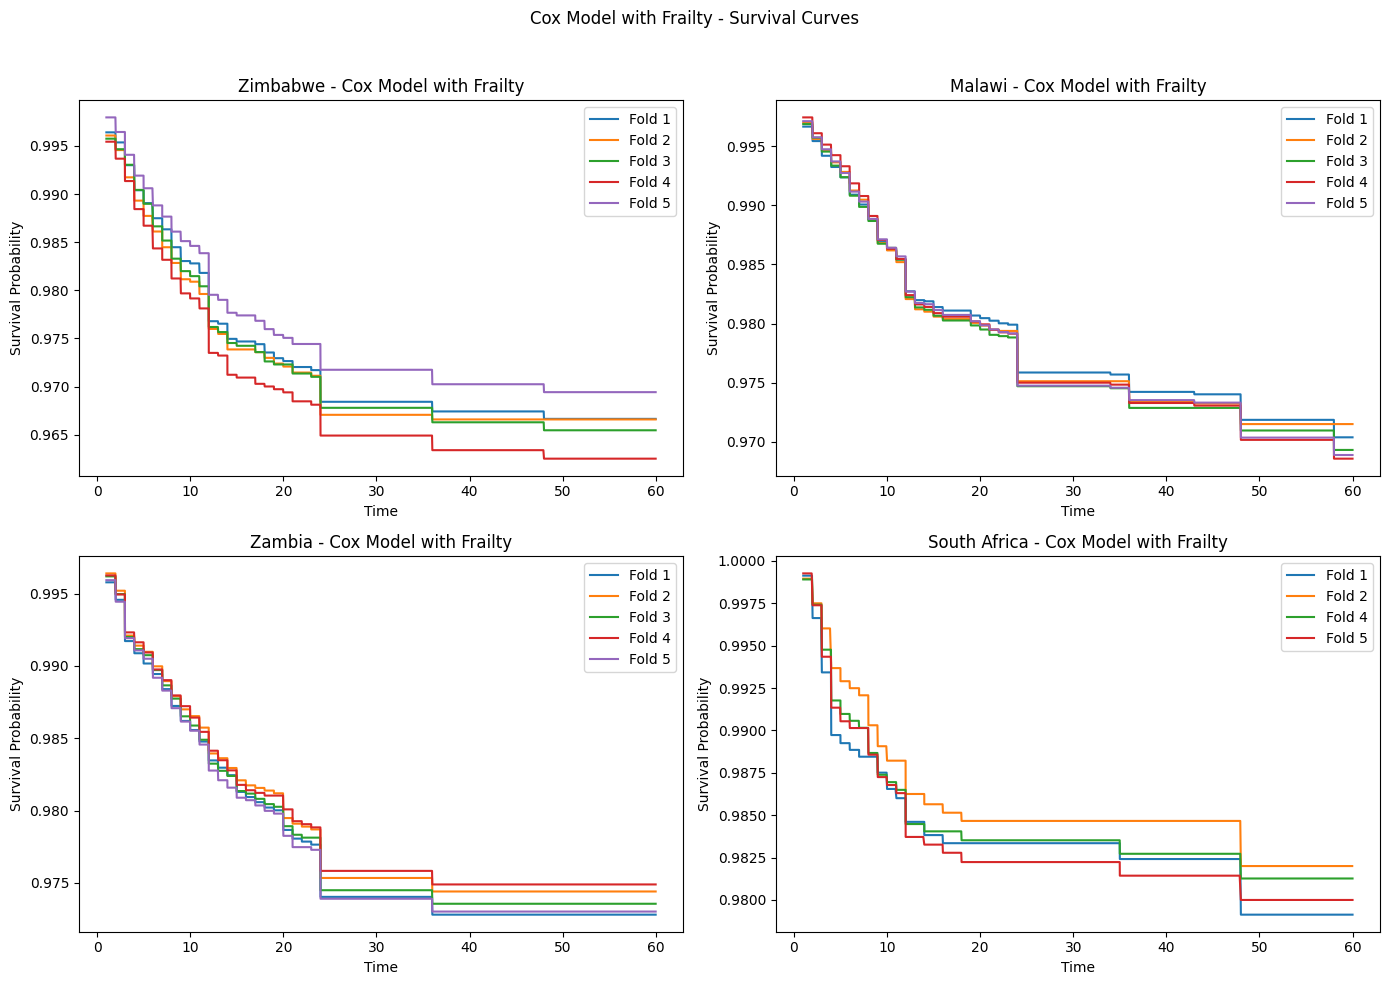

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from sklearn.model_selection import KFold

# Function to plot survival curves
def plot_survival_curves_cph_frailty(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        for fold_idx, surv in enumerate(surv_curves):
            if surv.empty or surv.shape[0] == 0:  # Skip empty survival curves
                continue
            times = surv.index
            survival_probs = surv.mean(axis=1)
            axes[i].plot(times, survival_probs, label=f'Fold {fold_idx + 1}')
        axes[i].set_title(f'{country} - Cox Model with Frailty')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend()
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Plots/cox_frailty_survival_curves.png')
    plt.show()

# Adjusted function to fit the Cox model with cross-validation and return survival curves
def fit_cox_model_cv(df, duration_col, event_col, strata_col, dataset_name, folds=5):
    df = df.copy()

    # Handle missing values and empty columns
    df = df.dropna()

    # Convert strata column to categorical
    if strata_col in df.columns:
        df[strata_col] = df[strata_col].astype('category')
    else:
        print(f"Column {strata_col} not found in dataset {dataset_name}.")
        return []

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]

        # Check if the training or validation sets are empty or too small
        if len(train_data) == 0 or len(val_data) == 0:
            print(f"Skipping fold {fold + 1} for {dataset_name} due to insufficient data.")
            continue
        
        try:
            # Ensure validation set has enough samples to avoid broadcasting issues
            if val_data.shape[0] < 3:
                print(f"Skipping fold {fold + 1} for {dataset_name}: insufficient samples in validation set.")
                continue

            # Fit the Cox model with the frailty term (using strata)
            cph = CoxPHFitter(penalizer=0.1)  # Adding penalizer to improve convergence
            cph.fit(train_data, duration_col=duration_col, event_col=event_col, strata=[strata_col])
            
            # Predict survival function for the validation set
            surv = cph.predict_survival_function(val_data)
            
            if surv.shape[0] > 0 and surv.shape[1] > 0:  # Only append if survival curve is not empty
                surv_curves.append(surv)
            else:
                surv_curves.append(pd.DataFrame())  # Append empty DataFrame if surv is invalid
            
        except Exception as e:
            print(f"Error fitting Cox model in fold {fold + 1} for {dataset_name}: {e}")
            surv_curves.append(pd.DataFrame())  # Append an empty DataFrame if the fold fails

    return surv_curves

# Collect the survival curves for each country using the Cox model with frailty
surv_curves_dict_cph_frailty = {
    'Zimbabwe': fit_cox_model_cv(zimbabwe_selected_df, 'survival_time', 'Status', 'V208_recoded', 'Zimbabwe'),
    'Malawi': fit_cox_model_cv(malawi_selected_df, 'survival_time', 'Status', 'V208_recoded', 'Malawi'),
    'Zambia': fit_cox_model_cv(zambia_selected_df, 'survival_time', 'Status', 'V208_recoded', 'Zambia'),
    'South Africa': fit_cox_model_cv(sa_selected_df, 'survival_time', 'Status', 'V208_recoded', 'South Africa')
}

# Plot all countries' survival curves in a 2x2 grid for Cox model with frailty
plot_survival_curves_cph_frailty(surv_curves_dict_cph_frailty, 'Cox Model with Frailty - Survival Curves')


In [43]:
def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from datetime import datetime

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    time_grid = np.linspace(0, 60, 100)  # Set fixed time horizon

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []  # Flatten all survival functions across folds
        for surv_funcs in surv_curves_per_fold:
            all_surv_funcs.extend(surv_funcs)

        # Evaluate all functions at the fixed time grid
        survival_matrix = np.array([[fn(t) for t in time_grid] for fn in all_surv_funcs])
        mean_survival = survival_matrix.mean(axis=0)

        # Plot
        axes[i].plot(time_grid, mean_survival, label='Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    plt.tight_layout()

    # Save the plot
    plots_folder = "C:/Users/cyrch/OneDrive - University of Witwatersrand/Desktop_hp/Side Projects/Mafa/Zim_Malawi_New/Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_file_path = os.path.join(plots_folder, f'RSF_Survival_Plots_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.png')
    plt.savefig(plot_file_path)
    plt.show()


NameError: name 'all_surv_funcs' is not defined

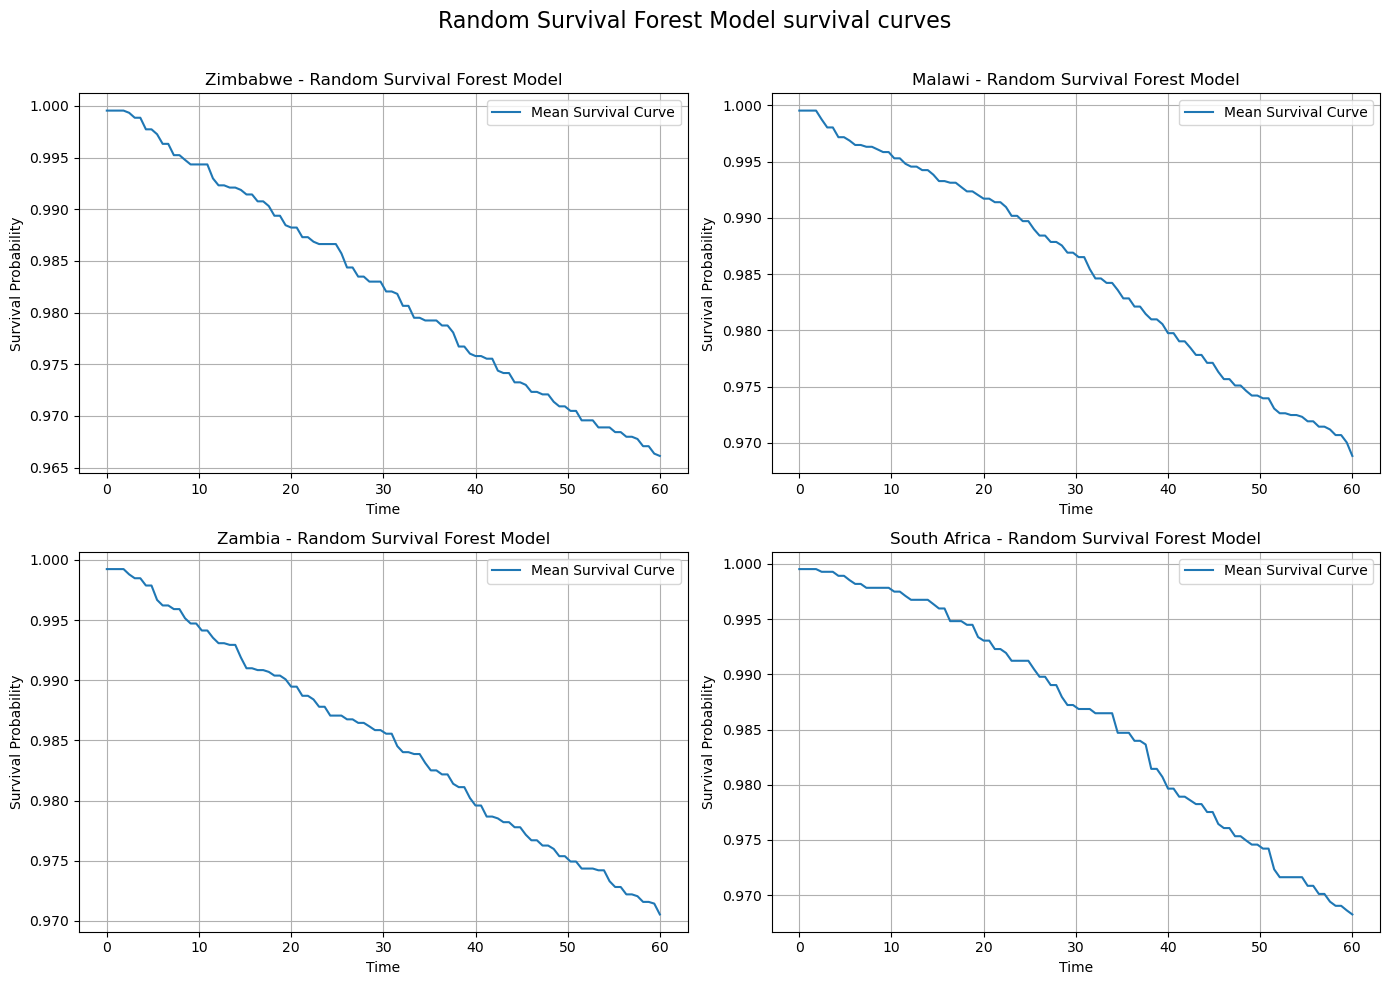

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from datetime import datetime

# ------------------------------------------------------------
# Function to fit RSF model and collect survival curves
# ------------------------------------------------------------
def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves

# ------------------------------------------------------------
# Function to safely plot mean RSF survival curves to time 60
# ------------------------------------------------------------
def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    time_grid = np.linspace(0, 60, 100)  # Fixed time grid

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]
            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        axes[i].plot(time_grid, mean_surv, label='Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    fig.suptitle('Random Survival Forest Model survival curves', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# ------------------------------------------------------------
# Example use — Replace these with your actual datasets
# ------------------------------------------------------------

# Example placeholders: replace with your DataFrames
# zimbabwe_selected_df = ...
# malawi_selected_df = ...
# zambia_selected_df = ...
# sa_selected_df = ...

surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')




In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from datetime import datetime
import os

# Optional: only works in Jupyter
try:
    from IPython.display import FileLink, display
    JUPYTER = True
except ImportError:
    JUPYTER = False

# ------------------------------------------------------------
# Function to fit RSF model and collect survival curves
# ------------------------------------------------------------
def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves

# ------------------------------------------------------------
# Function to plot, save, and show download link
# ------------------------------------------------------------
def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.flatten()
    time_grid = np.linspace(0, 60, 100)  # Fixed time grid

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]
            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        axes[i].plot(time_grid, mean_surv, label='Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}',fontsize=16)
        axes[i].set_xlabel('Time',fontsize=16)
        axes[i].set_ylabel('Survival Probability',fontsize=16)
        axes[i].legend(loc='best',fontsize=16)
        axes[i].grid(True)

    fig.suptitle('Random Survival Forest Model survival curves', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # ✅ Save the plot to current directory
    filename = f"RSF_Survival_Curves_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"
    fig.savefig(filename, dpi=300)
    print(f"✅ Plot saved as: {filename}")
    plt.show()

    # ✅ Show download link if in Jupyter
    if JUPYTER:
        display(FileLink(filename, result_html_prefix="📥 Click to download: "))


✅ Plot saved as: RSF_Survival_Curves_2026-01-21_10-43-18.pdf


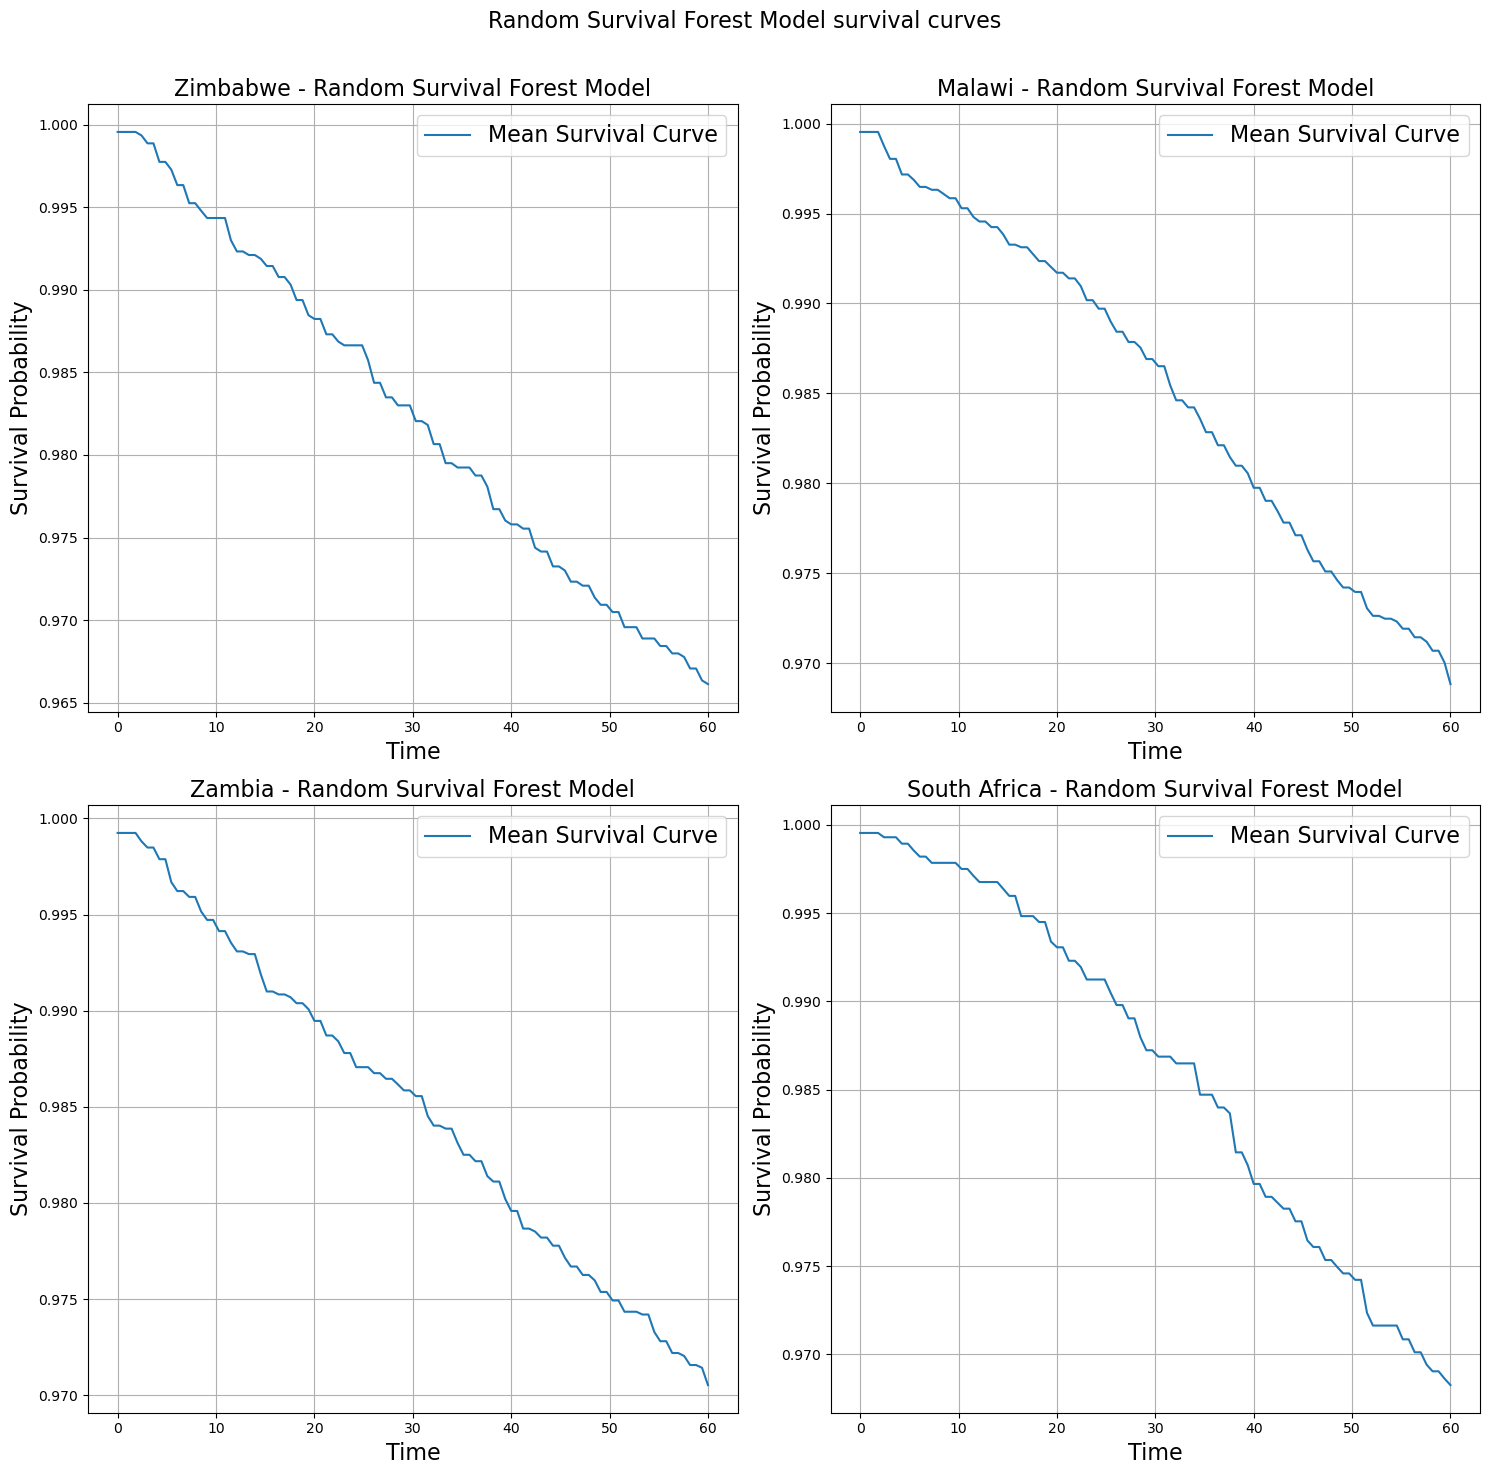

/home/justine/RSF_Survival_Curves_2026-01-21_10-43-18.pdf

In [92]:
# Replace with your actual DataFrames
surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')
